# 🛣️ Road Hazard Detection — Model 3 Pipeline

**Pipeline:**
- **Model 1 (Stage 1):** YOLOv8n trained on classical dataset → bounding-box proposals
- **Model 3 (Stage 2):** QuantumDetectionRefiner (ResNet18 + VQC) → class refinement

Run cells top-to-bottom. Google Colab T4 GPU recommended.
---

## 0. Install Dependencies

In [1]:
# Runtime: ANY (run first)
!pip install ultralytics pennylane pennylane-lightning -q
!pip install roboflow kaggle opencv-python-headless -q
!pip install scikit-learn matplotlib seaborn pandas tqdm -q
print("✅ All dependencies installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 116.

## 1. Dataset Download

In [2]:
%%writefile kaggle.json
{
  "username": "navanithd",
  "key": "KGAT_8a0c669c1568f8a55fdd0eec8694b89d"
}

Writing kaggle.json


In [3]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print("Kaggle API configured successfully.")

Kaggle API configured successfully.


In [4]:
!kaggle datasets download -d sabidrahman/pothole-cracks-and-openmanhole
!unzip pothole-cracks-and-openmanhole.zip -d pothole_dataset

Streaming output truncated to the last 5000 lines.
  inflating: pothole_dataset/dataset/dataset/train/images/1098_aug_vertical_flip.jpg  
  inflating: pothole_dataset/dataset/dataset/train/images/1099.jpg  
  inflating: pothole_dataset/dataset/dataset/train/images/1099_aug_brightness_contrast.jpg  
  inflating: pothole_dataset/dataset/dataset/train/images/1099_aug_flip.jpg  
  inflating: pothole_dataset/dataset/dataset/train/images/1099_aug_rotate.jpg  
  inflating: pothole_dataset/dataset/dataset/train/images/1099_aug_vertical_flip.jpg  
  inflating: pothole_dataset/dataset/dataset/train/images/109_aug_grayscale.jpg  
  inflating: pothole_dataset/dataset/dataset/train/images/109_augmented.jpg  
  inflating: pothole_dataset/dataset/dataset/train/images/10_aug_grayscale.jpg  
  inflating: pothole_dataset/dataset/dataset/train/images/10_augmented.jpg  
  inflating: pothole_dataset/dataset/dataset/train/images/11.jpg  
  inflating: pothole_dataset/dataset/dataset/train/images/110.jpg  
  

In [5]:
from roboflow import Roboflow
rf = Roboflow(api_key="tAeqbdjPN4qo0d426chI")
project = rf.workspace("garbage-detection-czeg5").project("garbage_detection-wvzwv")
dataset = project.version(18).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to garbage_detection-18 in yolov8:: 100%|██████████| 8386/8386 [00:01<00:00, 5696.02it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2. Dataset Preprocessing

In [6]:
import os
base_path = "/content/combined_dataset"
folders = [
    "train/images", "train/labels",
    "valid/images", "valid/labels",
    "test/images",  "test/labels"
]
for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)
print("✅ Combined dataset folders created.")
print("   Folder structure:")
for f in folders:
    print(f"   /content/combined_dataset/{f}")

✅ Combined dataset folders created.
   Folder structure:
   /content/combined_dataset/train/images
   /content/combined_dataset/train/labels
   /content/combined_dataset/valid/images
   /content/combined_dataset/valid/labels
   /content/combined_dataset/test/images
   /content/combined_dataset/test/labels


In [7]:
import shutil
from pathlib import Path

pothole_base  = Path("/content/pothole_dataset/dataset/dataset")
combined_base = Path("/content/combined_dataset")

class_map = {
    0: 0,  # cracks
    1: 1,  # open_manhole
    2: 2   # pothole
}

def process_split(split):
    images_src = pothole_base / split / "images"
    labels_src = pothole_base / split / "labels"
    images_dst = combined_base / split / "images"
    labels_dst = combined_base / split / "labels"
    copied = 0
    for label_file in labels_src.glob("*.txt"):
        new_lines = []
        with open(label_file, "r") as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            class_id = int(parts[0])
            if class_id in class_map:
                new_class_id = class_map[class_id]
                new_line = " ".join([str(new_class_id)] + parts[1:])
                new_lines.append(new_line)
        if new_lines:
            image_file = images_src / (label_file.stem + ".jpg")
            if not image_file.exists():
                image_file = images_src / (label_file.stem + ".png")
            if image_file.exists():
                shutil.copy(image_file, images_dst / image_file.name)
                with open(labels_dst / label_file.name, "w") as f:
                    f.write("\n".join(new_lines))
                copied += 1
    print(f"  {split:5s} → {copied} images+labels copied")

print("Merging pothole dataset…")
for split in ["train", "valid", "test"]:
    process_split(split)
print("✅ Pothole dataset merged.")

Merging pothole dataset…
  train → 2130 images+labels copied
  valid → 480 images+labels copied
  test  → 0 images+labels copied
✅ Pothole dataset merged.


In [8]:
garbage_base = Path("/content/garbage_detection-18")

def process_garbage(split):
    images_src = garbage_base / split / "images"
    labels_src = garbage_base / split / "labels"
    images_dst = combined_base / split / "images"
    labels_dst = combined_base / split / "labels"
    copied = 0
    for label_file in labels_src.glob("*.txt"):
        new_lines = []
        with open(label_file, "r") as f:
            lines = f.readlines()
        for line in lines:
            parts    = line.strip().split()
            new_line = " ".join(["3"] + parts[1:])  # class 3 = garbage
            new_lines.append(new_line)
        image_file = images_src / (label_file.stem + ".jpg")
        if not image_file.exists():
            image_file = images_src / (label_file.stem + ".png")
        if image_file.exists():
            shutil.copy(image_file, images_dst / image_file.name)
            with open(labels_dst / label_file.name, "w") as f:
                f.write("\n".join(new_lines))
            copied += 1
    print(f"  {split:5s} → {copied} images+labels copied")

print("Merging garbage dataset…")
for split in ["train", "valid", "test"]:
    process_garbage(split)
print("✅ Garbage dataset merged.")

Merging garbage dataset…
  train → 3669 images+labels copied
  valid → 260 images+labels copied
  test  → 258 images+labels copied
✅ Garbage dataset merged.


In [9]:
data_yaml_content = """
path: /content/combined_dataset

train: train/images
val:   valid/images
test:  test/images

nc: 4

names:
  0: cracks
  1: open_manhole
  2: pothole
  3: garbage
"""
with open("/content/combined_dataset/data.yaml", "w") as f:
    f.write(data_yaml_content)
print("✅ data.yaml created")
print(data_yaml_content)

✅ data.yaml created

path: /content/combined_dataset

train: train/images
val:   valid/images
test:  test/images

nc: 4

names:
  0: cracks
  1: open_manhole
  2: pothole
  3: garbage



In [10]:
# Dataset exploration summary removed for clean execution flow


In [11]:
# ╔══════════════════════════════════════════════════════════╗
# ║  DATASET BALANCING (Downsample Garbage Class)           ║
# ╚══════════════════════════════════════════════════════════╝

from pathlib import Path
import random
import shutil

base = Path("/content/combined_dataset")

TARGET_GARBAGE = 1000   # adjust (1500–2500 is safe)

def get_class_from_label(label_path):
    with open(label_path, "r") as f:
        lines = f.readlines()
    classes = [int(line.split()[0]) for line in lines]
    return classes

def balance_split(split):
    print(f"\n🔧 Balancing: {split}")

    img_dir = base / split / "images"
    lbl_dir = base / split / "labels"

    garbage_files = []

    for lbl_file in lbl_dir.glob("*.txt"):
        classes = get_class_from_label(lbl_file)

        # if ANY object is garbage → mark it
        if 3 in classes:
            garbage_files.append(lbl_file)

    print(f"   Found garbage samples: {len(garbage_files)}")

    if len(garbage_files) <= TARGET_GARBAGE:
        print("   No downsampling needed")
        return

    # randomly remove extra garbage samples
    remove_count = len(garbage_files) - TARGET_GARBAGE
    remove_files = random.sample(garbage_files, remove_count)

    for lbl_file in remove_files:
        img_file = img_dir / (lbl_file.stem + ".jpg")

        if img_file.exists():
            os.remove(img_file)
        os.remove(lbl_file)

    print(f"   Removed {remove_count} garbage samples")

# Apply to all splits
for split in ["train", "valid", "test"]:
    balance_split(split)

print("\n✅ Dataset balancing complete")


🔧 Balancing: train
   Found garbage samples: 3459
   Removed 2459 garbage samples

🔧 Balancing: valid
   Found garbage samples: 252
   No downsampling needed

🔧 Balancing: test
   Found garbage samples: 234
   No downsampling needed

✅ Dataset balancing complete


## 3. Imports & Global Configuration

In [12]:
# Runtime: ANY
import os, sys, shutil, time, warnings, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

import pennylane as qml
from ultralytics import YOLO
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────
CLASSICAL_DS = "/content/combined_dataset"
CROP_DS      = "/content/crop_dataset"
MODELS_DIR   = "/content/saved_models"
RESULTS_DIR  = "/content/results"

for base in [CROP_DS]:
    for split in ["train/images", "train/labels",
                  "valid/images", "valid/labels",
                  "test/images",  "test/labels"]:
        os.makedirs(f"{base}/{split}", exist_ok=True)

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Hardware ───────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n{'='*55}")
print("  HARDWARE INFO")
print(f"{'='*55}")
print(f"  Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU    : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print(f"  CUDA   : {torch.version.cuda}")
else:
    print("  CPU-only mode (quantum circuit will run here)")
print(f"  PyTorch: {torch.__version__}")
print(f"  PennyLane: {qml.__version__}")

# ── Class Config ───────────────────────────────────────────
CLASS_NAMES = ['cracks', 'open_manhole', 'pothole', 'garbage']
NUM_CLASSES = 4
IMG_SIZE    = 640
COLORS_BGR  = [(0,0,255), (0,255,0), (255,0,0), (0,165,255)]  # per class

print(f"\n  Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"  Image size for YOLO: {IMG_SIZE}×{IMG_SIZE}")

# ── Results container ──────────────────────────────────────
ALL_RESULTS = {}

print(f"\n{'='*55}")
print("  ✅ Config complete — Using ONLY Model 1 + Model 3")
print(f"{'='*55}")


  HARDWARE INFO
  Device : cuda
  GPU    : Tesla T4
  VRAM   : 15.6 GB
  CUDA   : 12.8
  PyTorch: 2.10.0+cu128
  PennyLane: 0.44.1

  Classes (4): ['cracks', 'open_manhole', 'pothole', 'garbage']
  Image size for YOLO: 640×640

  ✅ Config complete — Using ONLY Model 1 + Model 3


In [13]:
# Runtime: ANY
# ── Fix data.yaml to Ultralytics standard ──────────────────
YAML_TEMPLATE = """\
path: {path}
train: train/images
val:   valid/images
test:  test/images

nc: 4
names: ['cracks', 'open_manhole', 'pothole', 'garbage']
"""

with open(f"{CLASSICAL_DS}/data.yaml", "w") as f:
    f.write(YAML_TEMPLATE.format(path=CLASSICAL_DS))
print("✅ Classical data.yaml fixed")

def verify_dataset(base_path, name="Dataset"):
    base = Path(base_path)
    print(f"\n{'='*45}")
    print(f"  {name}: {base_path}")
    print(f"{'='*45}")
    total = 0
    for split in ["train", "valid", "test"]:
        imgs = list((base / split / "images").glob("*.*"))
        lbls = list((base / split / "labels").glob("*.txt"))
        print(f"  {split:5s} → {len(imgs):4d} images | {len(lbls):4d} labels")
        total += len(imgs)
    print(f"  TOTAL → {total} images")
    return total

verify_dataset(CLASSICAL_DS, "Classical Dataset")

✅ Classical data.yaml fixed

  Classical Dataset: /content/combined_dataset
  train → 3340 images | 3340 labels
  valid →  740 images |  740 labels
  test  →  258 images |  258 labels
  TOTAL → 4338 images


4338

## 4. Model 1 — Classical YOLOv8n (Bounding Box Proposer)

In [14]:
# ╔══════════════════════════════════════════════════════════╗
# ║  MODEL 1 — Classical Dataset + Classical YOLOv8n         ║
# ║  Purpose: bounding-box PROPOSER for Model 3 pipeline     ║
# ╚══════════════════════════════════════════════════════════╝

print("="*60)
print("  MODEL 1: Classical YOLOv8n — Architecture Inspection")
print("="*60)

model1 = YOLO('yolov8n.pt')

# ── Parameter count breakdown ──────────────────────────────
total_params     = sum(p.numel() for p in model1.model.parameters())
trainable_params = sum(p.numel() for p in model1.model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"\n📊 Parameter Count:")
print(f"   Total params     : {total_params:,}")
print(f"   Trainable params : {trainable_params:,}")
print(f"   Frozen params    : {frozen_params:,}")
print(f"   Model size (fp32): ~{total_params * 4 / 1e6:.1f} MB")

print(f"\n✅ Model 1 loaded — backbone: COCO pre-trained")
print(f"   Input  : 640×640×3 (BGR)")
print(f"   Output : bounding boxes [x1,y1,x2,y2], confidence, class")
print(f"   Classes: {NUM_CLASSES} ({CLASS_NAMES})")

  MODEL 1: Classical YOLOv8n — Architecture Inspection

📊 Parameter Count:
   Total params     : 3,157,200
   Trainable params : 0
   Frozen params    : 3,157,200
   Model size (fp32): ~12.6 MB

✅ Model 1 loaded — backbone: COCO pre-trained
   Input  : 640×640×3 (BGR)
   Output : bounding boxes [x1,y1,x2,y2], confidence, class
   Classes: 4 (['cracks', 'open_manhole', 'pothole', 'garbage'])


In [15]:
# ── Training Model 1 ──────────────────────────────────────
# Runtime: T4 GPU  |  ~15-25 min (50 epochs)

print("="*60)
print("  MODEL 1: Training YOLOv8n on Classical Dataset")
print("="*60)
print(f"  Data   : {CLASSICAL_DS}/data.yaml")
print(f"  Epochs : 40")
print(f"  Batch  : 16")
print(f"  ImgSz  : {IMG_SIZE}")
print(f"  Optim  : AdamW  LR=0.001  WD=0.0005")
print(f"  Device : {'GPU' if torch.cuda.is_available() else 'CPU'}")

t0_m1 = time.time()

results_m1 = model1.train(
    data         = f"{CLASSICAL_DS}/data.yaml",
    epochs       = 40,
    imgsz        = IMG_SIZE,
    batch        = 16,
    device       = 0 if torch.cuda.is_available() else 'cpu',
    project      = MODELS_DIR,
    name         = 'M1_classical_classical',
    exist_ok     = True,
    pretrained   = True,
    optimizer    = 'AdamW',
    lr0          = 0.001,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 0.0005,
    warmup_epochs= 3,
    mosaic       = 1.0,
    patience     = 15,
    save         = True,
    verbose      = True,
)

M1_TRAIN_TIME = time.time() - t0_m1
M1_WEIGHTS    = f"{MODELS_DIR}/M1_classical_classical/weights/best.pt"

print(f"\n✅ Model 1 training complete")
print(f"   Saved  → {M1_WEIGHTS}")
print(f"   ⏱️  Training time: {M1_TRAIN_TIME/60:.1f} min  ({M1_TRAIN_TIME:.0f}s)")

  MODEL 1: Training YOLOv8n on Classical Dataset
  Data   : /content/combined_dataset/data.yaml
  Epochs : 40
  Batch  : 16
  ImgSz  : 640
  Optim  : AdamW  LR=0.001  WD=0.0005
  Device : GPU
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/combined_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0,

In [16]:
# ── Validate Model 1 ──────────────────────────────────────
# Runtime: T4 GPU  |  ~3 min

print("\n📊 Validating Model 1 on Classical Test Set…")
model1_best = YOLO(M1_WEIGHTS)
metrics_m1  = model1_best.val(
    data    = f"{CLASSICAL_DS}/data.yaml",
    imgsz   = IMG_SIZE,
    batch   = 16,
    device  = 0 if torch.cuda.is_available() else 'cpu',
    verbose = True,
)

ALL_RESULTS['M1'] = {
    'name'         : 'Classical DS + Classical YOLOv8n',
    'mAP50'        : round(float(metrics_m1.box.map50), 4),
    'mAP50_95'     : round(float(metrics_m1.box.map),   4),
    'precision'    : round(float(metrics_m1.box.mp),    4),
    'recall'       : round(float(metrics_m1.box.mr),    4),
    'f1'           : round(2 * float(metrics_m1.box.mp) * float(metrics_m1.box.mr) /
                     max(float(metrics_m1.box.mp) + float(metrics_m1.box.mr), 1e-6), 4),
    'training_time': round(M1_TRAIN_TIME, 1),
}

print("\n" + "="*55)
print("  MODEL 1 — Validation Results")
print("="*55)
for k, v in ALL_RESULTS['M1'].items():
    if k == 'training_time':
        print(f"  {'training_time':20s}: {v:.1f}s  ({v/60:.1f} min)")
    else:
        print(f"  {k:20s}: {v}")

# Per-class mAP
print("\n  Per-class mAP50:")
for i, (cls, ap) in enumerate(zip(CLASS_NAMES, metrics_m1.box.ap50)):
    bar = '█' * int(float(ap) * 20)
    print(f"    {cls:14s} (class {i}): {float(ap):.4f}  {bar}")

print("\n✅ Model 1 evaluation done — weights will feed Model 3 pipeline")


📊 Validating Model 1 on Classical Test Set…
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2087.6±1136.5 MB/s, size: 223.6 KB)
val: Scanning /content/combined_dataset/valid/labels.cache... 740 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 740/740 344.9Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2, len(boxes) = 1014. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 5.1it/s 9.2s
                   all        740       1014      0.846      0.734      0.797      0.404
                cracks        182        425      0.848      0.553      0.682

## 5. Quantum VQC Architecture

In [17]:
# ╔══════════════════════════════════════════════════════════╗
# ║  QUANTUM-HYBRID ARCHITECTURE (VQC)                        ║
# ║  Stage 1 (Classical) : YOLO backbone → region crops      ║
# ║  Stage 2 (Quantum)   : ResNet18 → 512-d → 4-d → VQC     ║
# ╚══════════════════════════════════════════════════════════╝

N_QC_QUBITS = 4
N_QC_LAYERS = 3

print("="*60)
print("  QUANTUM CIRCUIT DEFINITION (VQC)")
print("="*60)
print(f"  Qubits  : {N_QC_QUBITS}")
print(f"  Layers  : {N_QC_LAYERS} (StronglyEntanglingLayers)")
print(f"  Backend : default.qubit (PennyLane)")
print(f"  Diff    : backprop (PyTorch-compatible)")
print("")
print("  Qubit roles:")
print("    q0, q1 → Position register (H superposition → 4 positions)")
print("    q2     → Feature qubit (ctrl-RY encodes feature per position)")
print("    q3     → Ancilla (CNOT + H: entanglement & interference)")

# ── Quantum device ─────────────────────────────────────────
_dev_clf = qml.device("default.qubit", wires=N_QC_QUBITS)
print(f"\n  Device: {_dev_clf.name}  |  Wires: {_dev_clf.wires}")


# Used by: QuantumDetectionRefiner.qlayer (via qml.qnn.TorchLayer)
@qml.qnode(_dev_clf, interface="torch", diff_method="backprop")
def _vqc(inputs, weights):
    """
    Variational Quantum Classifier (VQC).

    inputs  : [batch, 4] Tanh outputs ∈ [−1, 1] from classical pre_q layer
    weights : [N_QC_LAYERS, 4, 3] trainable variational parameters

    Encoding steps:
      1. Remap [−1,1] → [0, π]  (angle range for RY gates)
      2. H⊗H on q0, q1          (uniform position superposition)
      3. ctrl-RY(2θᵢ) on q2 for each position i ∈ {00,01,10,11}
         → encodes feature as rotation amplitude on q2
      4. CNOT(q2→q3) + H(q3)    (ancilla entanglement + interference)
      5. StronglyEntanglingLayers (variational classification)

    Returns: 4 PauliZ expectation values ∈ [−1, 1]
    """
    thetas = (inputs + 1.0) * (np.pi / 2.0)  # [−1,1] → [0, π]

    # Step 1: Uniform superposition over 4 positions
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)

    # Step 2: Feature encoding — ctrl-RY per position
    qml.ctrl(qml.RY, control=[0,1], control_values=[0,0])(2.0 * thetas[..., 0], wires=2)
    qml.ctrl(qml.RY, control=[0,1], control_values=[0,1])(2.0 * thetas[..., 1], wires=2)
    qml.ctrl(qml.RY, control=[0,1], control_values=[1,0])(2.0 * thetas[..., 2], wires=2)
    qml.ctrl(qml.RY, control=[0,1], control_values=[1,1])(2.0 * thetas[..., 3], wires=2)

    # Step 3: Ancilla entanglement + interference
    qml.CNOT(wires=[2, 3])
    qml.Hadamard(wires=3)

    # Step 4: Variational layers
    qml.StronglyEntanglingLayers(weights, wires=range(N_QC_QUBITS))

    return [qml.expval(qml.PauliZ(i)) for i in range(N_QC_QUBITS)]


_VQC_WEIGHT_SHAPES = {"weights": (N_QC_LAYERS, N_QC_QUBITS, 3)}
vqc_total_params   = N_QC_LAYERS * N_QC_QUBITS * 3
vqc_encoding_gates = 2 + 4 + 1 + 1  # HH + 4 ctrl-RY + CNOT + H
vqc_circuit_depth  = vqc_encoding_gates + N_QC_LAYERS * (N_QC_QUBITS + 3)  # approx

print("\n  VQC Circuit Summary:")
print(f"    Trainable weight params : {vqc_total_params}  "
      f"({N_QC_LAYERS} layers × {N_QC_QUBITS} qubits × 3 rotations)")
print(f"    Weight tensor shape     : ({N_QC_LAYERS}, {N_QC_QUBITS}, 3)")
print(f"    Encoding gates          : {vqc_encoding_gates}  "
      f"(2 Hadamard + 4 ctrl-RY + 1 CNOT + 1 Hadamard)")
print(f"    Est. circuit depth      : ~{vqc_circuit_depth} gates")
print(f"    Input bits (float32)    : {N_QC_QUBITS} × 32 = {N_QC_QUBITS*32} bits")
print(f"    Output                  : {N_QC_QUBITS} PauliZ expectation values")
print(f"    Output range            : [−1, 1] per qubit")

print("\n✅ Quantum VQC defined")

  QUANTUM CIRCUIT DEFINITION (VQC)
  Qubits  : 4
  Layers  : 3 (StronglyEntanglingLayers)
  Backend : default.qubit (PennyLane)
  Diff    : backprop (PyTorch-compatible)

  Qubit roles:
    q0, q1 → Position register (H superposition → 4 positions)
    q2     → Feature qubit (ctrl-RY encodes feature per position)
    q3     → Ancilla (CNOT + H: entanglement & interference)

  Device: default.qubit  |  Wires: Wires([0, 1, 2, 3])

  VQC Circuit Summary:
    Trainable weight params : 36  (3 layers × 4 qubits × 3 rotations)
    Weight tensor shape     : (3, 4, 3)
    Encoding gates          : 8  (2 Hadamard + 4 ctrl-RY + 1 CNOT + 1 Hadamard)
    Est. circuit depth      : ~29 gates
    Input bits (float32)    : 4 × 32 = 128 bits
    Output                  : 4 PauliZ expectation values
    Output range            : [−1, 1] per qubit

✅ Quantum VQC defined


In [18]:
# ── QuantumDetectionRefiner full architecture ──────────────

# Used by: model3 (Cell 29 training), model3_eval (Cell 32 eval), infer_m3 (Cell 38/40/42 inference)
class QuantumDetectionRefiner(nn.Module):
    """
    Quantum-Classical Hybrid classifier for cropped object regions.

    Architecture:
      [crop 64×64×3]
          ↓
      ResNet18 backbone (frozen, COCO pre-trained)
          ↓ [B, 512, 1, 1]
      Flatten → Linear(512→64) → ReLU → Linear(64→4) → Tanh
          ↓ [B, 4]  ∈ [−1, 1]
      VQC (4 qubits, 3 variational layers)
          ↓ [B, 4]  PauliZ expectations
      Linear(4→32) → ReLU → Dropout(0.3) → Linear(32→n_classes)
          ↓ [B, n_classes]  logits

    Boxes come from Stage-1 (Model 1 / YOLO). This model refines class.
    """

    def __init__(self, n_classes=4):
        super().__init__()

        # ── Classical Backbone (frozen) ──────────────────────
        resnet = models.resnet18(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        for p in self.backbone.parameters():
            p.requires_grad = False

        # ── Classical Projection ─────────────────────────────
        self.pre_q = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Linear(64, N_QC_QUBITS),
            nn.Tanh(),
        )

        # ── Quantum Layer ────────────────────────────────────
        self.qlayer = qml.qnn.TorchLayer(_vqc, _VQC_WEIGHT_SHAPES)

        # ── Post-Quantum Head ────────────────────────────────
        self.post_q = nn.Sequential(
            nn.Linear(N_QC_QUBITS, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        feats  = self.backbone(x)   # [B, 512, 1, 1]
        q_in   = self.pre_q(feats)  # [B, 4]
        q_out  = self.qlayer(q_in)  # [B, 4]
        logits = self.post_q(q_out) # [B, n_classes]
        return logits


# ── Crop transforms ──────────────────────────────────────────
CROP_TF = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

print("="*60)
print("  MODEL 3 ARCHITECTURE: QuantumDetectionRefiner")
print("="*60)

_test_model = QuantumDetectionRefiner(n_classes=NUM_CLASSES)

# ── Parameter breakdown ──────────────────────────────────────
total_all      = sum(p.numel() for p in _test_model.parameters())
total_trainable= sum(p.numel() for p in _test_model.parameters() if p.requires_grad)
total_frozen   = total_all - total_trainable

print(f"\n📊 Parameter Breakdown:")
print(f"   {'Component':<30} {'Params':>12} {'Trainable':>12} {'Bits (fp32)':>14}")
print(f"   {'-'*70}")

components = [
    ('backbone (ResNet18, frozen)', _test_model.backbone),
    ('pre_q (classical projection)', _test_model.pre_q),
    ('qlayer (VQC)',                 _test_model.qlayer),
    ('post_q (classifier head)',     _test_model.post_q),
]
for name, mod in components:
    p_total = sum(x.numel() for x in mod.parameters())
    p_train = sum(x.numel() for x in mod.parameters() if x.requires_grad)
    print(f"   {name:<30} {p_total:>12,} {p_train:>12,} {p_total*32:>14,}")

print(f"   {'-'*70}")
print(f"   {'TOTAL':<30} {total_all:>12,} {total_trainable:>12,} {total_all*32:>14,}")
print(f"\n   Model size (fp32)   : ~{total_all * 4 / 1e6:.2f} MB")
print(f"   Frozen backbone     : {total_frozen:,} params  (ResNet18 weights)")
print(f"   Optimized params    : {total_trainable:,} params  (pre_q + VQC + post_q)")

print(f"\n✅ Architecture verified — ready for training")

  MODEL 3 ARCHITECTURE: QuantumDetectionRefiner
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


📊 Parameter Breakdown:
   Component                            Params    Trainable    Bits (fp32)
   ----------------------------------------------------------------------
   backbone (ResNet18, frozen)      11,176,512            0    357,648,384
   pre_q (classical projection)         33,092       33,092      1,058,944
   qlayer (VQC)                             36           36          1,152
   post_q (classifier head)                292          292          9,344
   ----------------------------------------------------------------------
   TOTAL                            11,209,932       33,420    358,717,824

   Model size (fp32)   : ~44.84 MB
   Frozen backbone     : 11,176,512 params  (ResNet18 weights)
   Optimized params    : 33,420 params  (pre_q + VQC + post_q)

✅ Architecture verified — ready for training


## 6. Crop Dataset — Extract Bounding Box Crops for Model 3

In [19]:
# ── CropDataset: crop once at load time, store tensors ──────────────────────
# Crops are extracted and transformed ONCE during __init__.
# __getitem__ returns a pre-computed tensor — zero repeated I/O per epoch.

class CropDataset(Dataset):
    """
    Extracts bounding-box crops from a YOLO-format detection dataset.
    Used to train the QuantumDetectionRefiner (Model 3).

    All crops are:
      - Extracted from disk once during __init__
      - Resized, converted to tensor, and normalized immediately
      - Stored as (tensor [C,H,W], int label) tuples in self.samples

    __getitem__ just indexes self.samples — no file I/O, no re-cropping,
    no re-transforming per epoch.
    """

    def __init__(self, images_dir, labels_dir, transform=None, max_crops=5000):
        self.samples = []   # list of (tensor, label_int)
        img_dir = Path(images_dir)
        lbl_dir = Path(labels_dir)
        count   = 0

        for lbl_path in sorted(lbl_dir.glob("*.txt")):
            if count >= max_crops:
                break
            img_path = img_dir / (lbl_path.stem + ".jpg")
            if not img_path.exists():
                img_path = img_dir / (lbl_path.stem + ".png")
            if not img_path.exists():
                continue

            img = cv2.imread(str(img_path))
            if img is None:
                continue
            h, w = img.shape[:2]

            with open(lbl_path) as f:
                lines = f.readlines()

            for line in lines:
                if count >= max_crops:
                    break
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id          = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:])

                # YOLO normalized → pixel coords
                x1 = max(0, int((xc - bw/2) * w))
                y1 = max(0, int((yc - bh/2) * h))
                x2 = min(w, int((xc + bw/2) * w))
                y2 = min(h, int((yc + bh/2) * h))

                if (x2 - x1) < 8 or (y2 - y1) < 8:
                    continue

                crop     = img[y1:y2, x1:x2]
                crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                crop_pil = Image.fromarray(crop_rgb)

                # Apply transform once here — result is a tensor
                tensor = transform(crop_pil) if transform else T.ToTensor()(crop_pil)

                self.samples.append((tensor, cls_id))
                count += 1

        print(f"  Loaded {len(self.samples)} crops (pre-transformed tensors) from {images_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # Direct lookup — no I/O, no transform, no PIL conversion
        return self.samples[idx]


# ── Build classical crop datasets ──────────────────────────────────────────
print("\n" + "="*60)
print("  BUILDING CLASSICAL CROP DATASETS")
print("  (crops extracted & transformed once — stored as tensors)")
print("="*60)

clf_train = CropDataset(f"{CLASSICAL_DS}/train/images",
                        f"{CLASSICAL_DS}/train/labels",
                        transform=CROP_TF, max_crops=5000)
clf_valid = CropDataset(f"{CLASSICAL_DS}/valid/images",
                        f"{CLASSICAL_DS}/valid/labels",
                        transform=CROP_TF, max_crops=1000)
clf_test  = CropDataset(f"{CLASSICAL_DS}/test/images",
                        f"{CLASSICAL_DS}/test/labels",
                        transform=CROP_TF, max_crops=500)


# ── Class distribution stats ────────────────────────────────────────────────
def print_class_dist(dataset, name):
    from collections import Counter
    counts = Counter(lbl for _, lbl in dataset.samples)
    total  = sum(counts.values())
    print(f"\n  📦 {name}:")
    print(f"     Total crops: {total}")
    print(f"     {'Class':<20} {'Count':>6} {'%':>6}  {'Bar'}")
    print(f"     {'-'*55}")
    for cid, cname in enumerate(CLASS_NAMES):
        cnt = counts.get(cid, 0)
        pct = cnt / total * 100 if total > 0 else 0
        bar = '█' * int(pct / 5)
        print(f"     {cid}: {cname:<16} {cnt:>6} {pct:>5.1f}%  {bar}")

print_class_dist(clf_train, "TRAIN crops")
print_class_dist(clf_valid, "VALID crops")
print_class_dist(clf_test,  "TEST  crops")


print(f"\n✅ Crop datasets ready — tensors stored in memory, zero re-cropping during training")



  BUILDING CLASSICAL CROP DATASETS
  (crops extracted & transformed once — stored as tensors)
  Loaded 3738 crops (pre-transformed tensors) from /content/combined_dataset/train/images
  Loaded 994 crops (pre-transformed tensors) from /content/combined_dataset/valid/images
  Loaded 273 crops (pre-transformed tensors) from /content/combined_dataset/test/images

  📦 TRAIN crops:
     Total crops: 3738
     Class                 Count      %  Bar
     -------------------------------------------------------
     0: cracks             1080  28.9%  █████
     1: open_manhole        868  23.2%  ████
     2: pothole             680  18.2%  ███
     3: garbage            1110  29.7%  █████

  📦 VALID crops:
     Total crops: 994
     Class                 Count      %  Bar
     -------------------------------------------------------
     0: cracks              407  40.9%  ████████
     1: open_manhole        170  17.1%  ███
     2: pothole             148  14.9%  ██
     3: garbage             

## 7. Training & Evaluation Utilities

In [20]:
# Used by: Cell 29 — trains model3 on clf_train/clf_valid
def train_quantum_model(model, train_ds, valid_ds,
                        epochs=40, batch_size=8, lr=0.005,
                        model_name="quantum_model"):
    """
    Train QuantumDetectionRefiner.

    Notes:
    - Small batch_size (8): keeps quantum simulation stable
    - Backbone frozen: only pre_q + VQC + post_q are optimized
    - Optimizer: Adam with cosine annealing LR schedule
    - Gradient clipping (max_norm=1.0) for stability

    Returns: model, history, save_path, training_time_seconds
    """
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=False)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=False)

    model     = model.cpu()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr * 0.01)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    best_val_acc = 0.0
    save_path    = f"{MODELS_DIR}/{model_name}.pth"

    # ── Optimizer summary ────────────────────────────────
    optimized_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f"  TRAINING: {model_name}")
    print(f"{'='*60}")
    print(f"  Epochs            : {epochs}")
    print(f"  Batch size        : {batch_size}")
    print(f"  Learning rate     : {lr} (cosine decay → {lr*0.01:.5f})")
    print(f"  Optimizer         : Adam + CosineAnnealingLR")
    print(f"  Loss function     : CrossEntropyLoss")
    print(f"  Gradient clipping : max_norm=1.0")
    print(f"  Optimized params  : {optimized_params:,}  (frozen backbone excluded)")
    print(f"  Train batches/ep  : {len(train_loader)}")
    print(f"  Valid batches/ep  : {len(valid_loader)}")
    print(f"  Device            : CPU (quantum sim requires CPU)")
    print(f"{'─'*60}")
    print(f"  {'Epoch':>6} {'TrLoss':>9} {'ValLoss':>9} {'TrAcc':>8} {'ValAcc':>8} {'LR':>10} {'Time':>8}")
    print(f"  {'─'*60}")

    train_start = time.time()

    for epoch in range(1, epochs + 1):
        # ── Train epoch ─────────────────────────────────
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs   = imgs.cpu()
            labels = labels.cpu()
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss    += loss.item() * imgs.size(0)
            t_correct += (logits.argmax(dim=1) == labels).sum().item()
            t_total   += imgs.size(0)

        # ── Validate epoch ───────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in valid_loader:
                imgs   = imgs.cpu()
                labels = labels.cpu()
                logits = model(imgs)
                loss   = criterion(logits, labels)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (logits.argmax(dim=1) == labels).sum().item()
                v_total   += imgs.size(0)

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        tr_loss = t_loss / t_total
        vl_loss = v_loss / v_total
        tr_acc  = t_correct / t_total
        vl_acc  = v_correct / v_total

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        is_best = vl_acc > best_val_acc
        if is_best:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), save_path)

        if epoch % 5 == 0 or epoch == 1 or is_best:
            elapsed = time.time() - train_start
            star    = ' ★' if is_best else ''
            print(f"  {epoch:>6} {tr_loss:>9.4f} {vl_loss:>9.4f} "
                  f"{tr_acc:>8.4f} {vl_acc:>8.4f} {current_lr:>10.6f} "
                  f"{elapsed/60:>6.1f}m{star}")

    training_time = time.time() - train_start

    print(f"\n  {'='*55}")
    print(f"  Best Val Accuracy : {best_val_acc:.4f}")
    print(f"  Final LR          : {current_lr:.6f}")
    print(f"  Training time     : {training_time:.0f}s  ({training_time/60:.1f} min)")
    print(f"  Saved → {save_path}")

    return model, history, save_path, training_time


# Used by: Cell 32 — evaluates model3_eval on clf_valid and clf_test
def evaluate_quantum_model(model, dataset, batch_size=8, split_name="valid"):
    """Full evaluation: accuracy, precision, recall, F1, confusion matrix."""
    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=False, num_workers=2)
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            logits = model(imgs.cpu())
            probs  = torch.softmax(logits, dim=1)
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    p, r, f, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)

    print(f"\n  📊 Evaluation on {split_name.upper()} split ({len(dataset)} samples):")
    print(f"  {'─'*50}")
    print(f"  Overall Accuracy : {acc:.4f}  ({int(acc*len(dataset))}/{len(dataset)} correct)")
    print(f"  Precision (wtd)  : {p:.4f}")
    print(f"  Recall (wtd)     : {r:.4f}")
    print(f"  F1 (wtd)         : {f:.4f}")

    print(f"\n  Per-class Classification Report:")
    print(classification_report(all_labels, all_preds,
                                target_names=CLASS_NAMES, zero_division=0))

    # ── Confusion matrix ─────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)
    print(f"  Confusion Matrix:")
    print(f"  Rows=True, Cols=Predicted  |  Classes: {CLASS_NAMES}")
    hdr = "  " + " ".join(f"{n[:4]:>6}" for n in CLASS_NAMES)
    print(hdr)
    for i, row in enumerate(cm):
        print(f"  {CLASS_NAMES[i][:8]:<10}" + " ".join(f"{v:>6}" for v in row))

    # ── Per-class confidence stats ────────────────────────
    print(f"\n  Per-class Softmax Confidence Stats:")
    print(f"  {'Class':<16} {'Mean Conf':>10} {'Min Conf':>10} {'Max Conf':>10}")
    for cid, cname in enumerate(CLASS_NAMES):
        mask = all_labels == cid
        if mask.sum() > 0:
            confs = all_probs[mask, cid]
            print(f"  {cname:<16} {confs.mean():>10.4f} {confs.min():>10.4f} {confs.max():>10.4f}")

    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f}


print("✅ Training utilities defined")

✅ Training utilities defined


## 8. Model 3 — Train Quantum-Hybrid Classifier

In [21]:
# ╔══════════════════════════════════════════════════════════╗
# ║  MODEL 3 — Classical Dataset + Quantum-Hybrid Detector   ║
# ║  Runtime: CPU (quantum sim)  |  ~20-35 min               ║
# ╚══════════════════════════════════════════════════════════╝

print("="*60)
print("  MODEL 3: Classical Dataset + Quantum-Hybrid Classifier")
print("="*60)

model3 = QuantumDetectionRefiner(n_classes=NUM_CLASSES)

# ── Print full architecture before training ─────────────────
print("\n  Full model architecture:")
print(model3)

# ── Count params before training ────────────────────────────
_n_total  = sum(p.numel() for p in model3.parameters())
_n_train  = sum(p.numel() for p in model3.parameters() if p.requires_grad)
print(f"\n  Params to optimize: {_n_train:,} / {_n_total:,} total")
print(f"  VQC weight shape  : {list(_VQC_WEIGHT_SHAPES['weights'])}")
print(f"  VQC params        : {N_QC_LAYERS * N_QC_QUBITS * 3}  "
      f"({N_QC_LAYERS}L × {N_QC_QUBITS}Q × 3)")

model3, history3, M3_WEIGHTS, M3_TRAIN_TIME = train_quantum_model(
    model      = model3,
    train_ds   = clf_train,
    valid_ds   = clf_valid,
    epochs     = 50,
    batch_size = 8,
    lr         = 0.005,
    model_name = "M3_classical_quantum",
)

# ── Print training history summary ──────────────────────────
print(f"\n  Training History Summary:")
print(f"  {'Metric':<20} {'Initial':>10} {'Final':>10} {'Best':>10}")
print(f"  {'─'*52}")
for metric in ['train_loss', 'val_loss', 'train_acc', 'val_acc']:
    vals = history3[metric]
    if 'loss' in metric:
        best = min(vals)
    else:
        best = max(vals)
    print(f"  {metric:<20} {vals[0]:>10.4f} {vals[-1]:>10.4f} {best:>10.4f}")

print(f"\n✅ Model 3 training complete")

  MODEL 3: Classical Dataset + Quantum-Hybrid Classifier

  Full model architecture:
QuantumDetectionRefiner(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

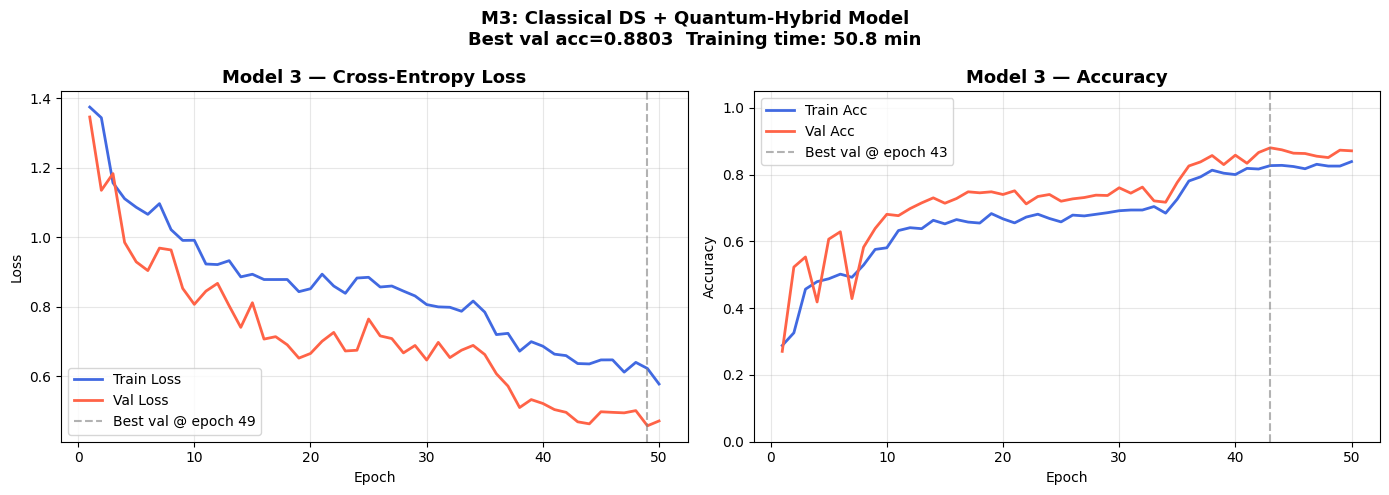

✅ Saved → /content/results/M3_training_curves.png

  Full Epoch Log:
    Ep    TrLoss   ValLoss    TrAcc   ValAcc
  ─────────────────────────────────────────────
     1    1.3741    1.3456   0.2881   0.2706
     2    1.3434    1.1348   0.3261   0.5231
     3    1.1563    1.1830   0.4569   0.5533
     4    1.1108    0.9852   0.4794   0.4185
     5    1.0861    0.9293   0.4880   0.6066
     6    1.0658    0.9042   0.5019   0.6288
     7    1.0966    0.9688   0.4925   0.4286
     8    1.0218    0.9634   0.5292   0.5825
     9    0.9909    0.8530   0.5760   0.6388
    10    0.9913    0.8071   0.5808   0.6811
    11    0.9231    0.8451   0.6324   0.6771
    12    0.9215    0.8674   0.6410   0.6982
    13    0.9327    0.8030   0.6380   0.7153
    14    0.8861    0.7410   0.6632   0.7304
    15    0.8937    0.8118   0.6525   0.7143
    16    0.8785    0.7073   0.6653   0.7284
    17    0.8784    0.7142   0.6578   0.7485
    18    0.8785    0.6909   0.6549   0.7455
    19    0.8436    0.6526  

In [22]:
# ── Plot training curves ────────────────────────────────────
epochs_range = range(1, len(history3['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history3['train_loss'], label='Train Loss', color='royalblue', lw=2)
axes[0].plot(epochs_range, history3['val_loss'],   label='Val Loss',   color='tomato',    lw=2)
axes[0].set_title('Model 3 — Cross-Entropy Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch');  axes[0].set_ylabel('Loss')
axes[0].legend();              axes[0].grid(alpha=0.3)

best_epoch_loss = int(np.argmin(history3['val_loss'])) + 1
axes[0].axvline(best_epoch_loss, color='gray', linestyle='--', alpha=0.6,
                label=f'Best val @ epoch {best_epoch_loss}')
axes[0].legend()

axes[1].plot(epochs_range, history3['train_acc'], label='Train Acc', color='royalblue', lw=2)
axes[1].plot(epochs_range, history3['val_acc'],   label='Val Acc',   color='tomato',    lw=2)
axes[1].set_title('Model 3 — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch');  axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05);    axes[1].legend(); axes[1].grid(alpha=0.3)

best_epoch_acc = int(np.argmax(history3['val_acc'])) + 1
axes[1].axvline(best_epoch_acc, color='gray', linestyle='--', alpha=0.6,
                label=f'Best val @ epoch {best_epoch_acc}')
axes[1].legend()

plt.suptitle(f"M3: Classical DS + Quantum-Hybrid Model\n"
             f"Best val acc={max(history3['val_acc']):.4f}  "
             f"Training time: {M3_TRAIN_TIME/60:.1f} min",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/M3_training_curves.png", dpi=150)
plt.show()
print(f"✅ Saved → {RESULTS_DIR}/M3_training_curves.png")

# ── Print epoch-by-epoch table ──────────────────────────────
print(f"\n  Full Epoch Log:")
print(f"  {'Ep':>4} {'TrLoss':>9} {'ValLoss':>9} {'TrAcc':>8} {'ValAcc':>8}")
print(f"  {'─'*45}")
for ep, (tl, vl, ta, va) in enumerate(
    zip(history3['train_loss'], history3['val_loss'],
        history3['train_acc'],  history3['val_acc']), 1):
    star = ' ←best' if va == max(history3['val_acc']) else ''
    print(f"  {ep:>4} {tl:>9.4f} {vl:>9.4f} {ta:>8.4f} {va:>8.4f}{star}")

## 9. Model 3 — Evaluate

In [23]:
# ── Load best checkpoint and evaluate ──────────────────────
print("="*60)
print("  MODEL 3 — Evaluation (Best Checkpoint)")
print("="*60)

model3_eval = QuantumDetectionRefiner(n_classes=NUM_CLASSES)
model3_eval.load_state_dict(torch.load(M3_WEIGHTS, map_location='cpu'))
model3_eval.eval()
print(f"  Loaded weights from: {M3_WEIGHTS}")


# ── Evaluate on valid and test splits ─────────────────────
print("\n" + "═"*60)

metrics3_valid = evaluate_quantum_model(model3_eval, clf_valid,
                                        split_name="valid")
print("\n" + "═"*60)
metrics3_test  = evaluate_quantum_model(model3_eval, clf_test,
                                        split_name="test")

# ── Store results ──────────────────────────────────────────
ALL_RESULTS['M3'] = {
    'name'         : 'Classical DS + Quantum-Hybrid Model',
    'mAP50'        : round(ALL_RESULTS['M1']['mAP50'] * metrics3_valid['accuracy'], 4),
    'mAP50_95'     : round(ALL_RESULTS['M1']['mAP50_95'] * metrics3_valid['accuracy'], 4),
    'precision'    : round(metrics3_valid['precision'], 4),
    'recall'       : round(metrics3_valid['recall'],    4),
    'f1'           : round(metrics3_valid['f1'],        4),
    'val_accuracy' : round(metrics3_valid['accuracy'],  4),
    'test_accuracy': round(metrics3_test['accuracy'],   4),
    'training_time': round(M3_TRAIN_TIME, 1),
}

print(f"\n{'='*60}")
print(f"  MODEL 3 — Final Summary")
print(f"{'='*60}")
for k, v in ALL_RESULTS['M3'].items():
    if k == 'training_time':
        print(f"  {k:<20}: {v:.1f}s  ({v/60:.1f} min)")
    else:
        print(f"  {k:<20}: {v}")

print(f"\n  Note: mAP50 = M1_mAP50 × M3_accuracy (hybrid mAP proxy)")
print(f"    M1 mAP50         : {ALL_RESULTS['M1']['mAP50']}")
print(f"    M3 val accuracy  : {metrics3_valid['accuracy']:.4f}")
print(f"    Hybrid mAP50     : {ALL_RESULTS['M3']['mAP50']}")

  MODEL 3 — Evaluation (Best Checkpoint)
  Loaded weights from: /content/saved_models/M3_classical_quantum.pth

════════════════════════════════════════════════════════════

  📊 Evaluation on VALID split (994 samples):
  ──────────────────────────────────────────────────
  Overall Accuracy : 0.8803  (875/994 correct)
  Precision (wtd)  : 0.8818
  Recall (wtd)     : 0.8803
  F1 (wtd)         : 0.8806

  Per-class Classification Report:
              precision    recall  f1-score   support

      cracks       0.89      0.87      0.88       407
open_manhole       0.90      0.85      0.88       170
     pothole       0.78      0.86      0.82       148
     garbage       0.91      0.92      0.91       269

    accuracy                           0.88       994
   macro avg       0.87      0.88      0.87       994
weighted avg       0.88      0.88      0.88       994

  Confusion Matrix:
  Rows=True, Cols=Predicted  |  Classes: ['cracks', 'open_manhole', 'pothole', 'garbage']
    crac   open 

## 12. Output Generation — Visualizations & Evaluation Plots

Generating ResNet feature output visualization...


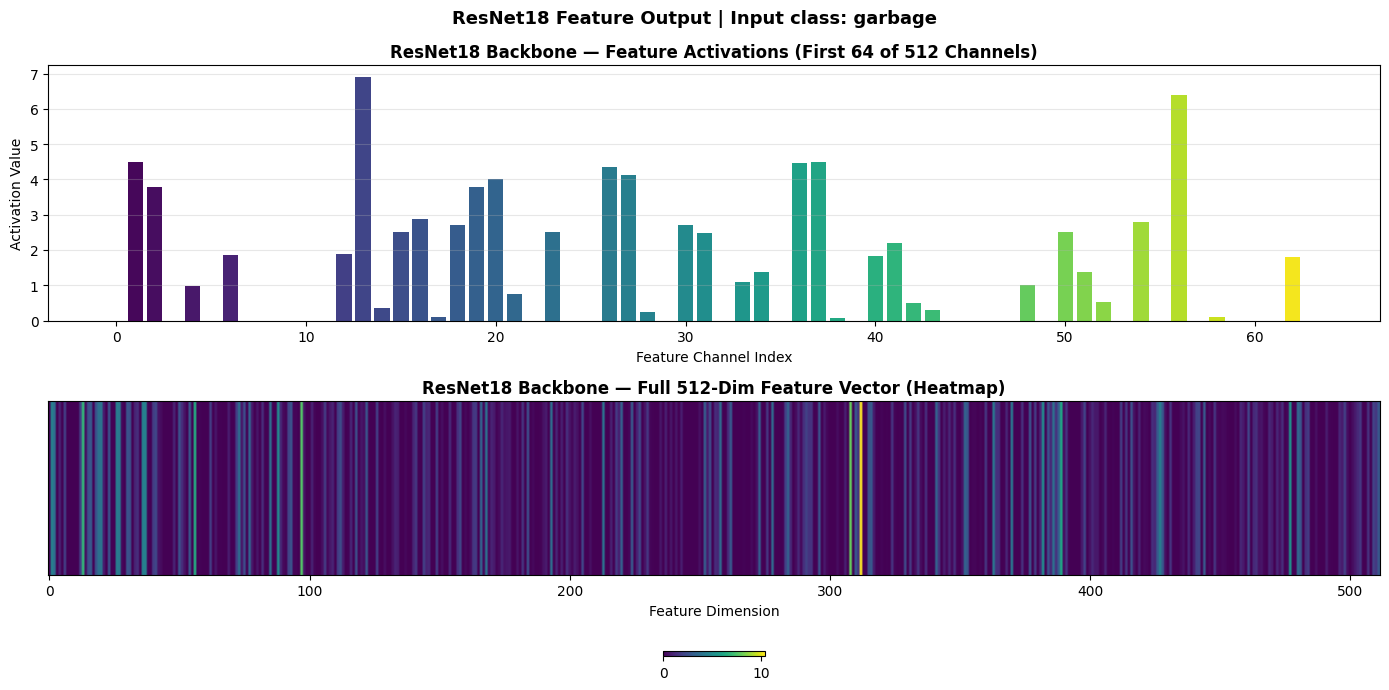

✅ Saved → /content/results/resnet_output.png


In [24]:
# ── ResNet Feature Output Visualization ────────────────────────────────────
# Uses the backbone of the trained model3_eval to extract feature maps
# and visualizes the 512-dim feature vector as a heatmap bar chart.

import matplotlib.pyplot as plt
import numpy as np
import torch

print("Generating ResNet feature output visualization...")

model3_eval.eval()

# Get a sample crop from the test set
sample_tensor, sample_label = clf_test[0]
input_tensor = sample_tensor.unsqueeze(0).cpu()

# Extract ResNet backbone features
with torch.no_grad():
    resnet_features = model3_eval.backbone(input_tensor)  # [1, 512, 1, 1]
    resnet_features_flat = resnet_features.squeeze().cpu().numpy()  # [512]

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Top: Feature activation bar chart (first 64 channels for readability)
axes[0].bar(range(64), resnet_features_flat[:64],
            color=plt.cm.viridis(np.linspace(0, 1, 64)), width=0.8)
axes[0].set_title('ResNet18 Backbone — Feature Activations (First 64 of 512 Channels)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature Channel Index')
axes[0].set_ylabel('Activation Value')
axes[0].grid(axis='y', alpha=0.3)

# Bottom: Full 512-dim feature as heatmap row
feat_reshaped = resnet_features_flat.reshape(1, 512)
im = axes[1].imshow(feat_reshaped, aspect='auto', cmap='viridis')
axes[1].set_title('ResNet18 Backbone — Full 512-Dim Feature Vector (Heatmap)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature Dimension')
axes[1].set_yticks([])
plt.colorbar(im, ax=axes[1], orientation='horizontal', pad=0.3, fraction=0.02)

plt.suptitle(f'ResNet18 Feature Output | Input class: {CLASS_NAMES[sample_label]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/resnet_output.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {RESULTS_DIR}/resnet_output.png")


Generating MLP latent (4D quantum input) output visualization...


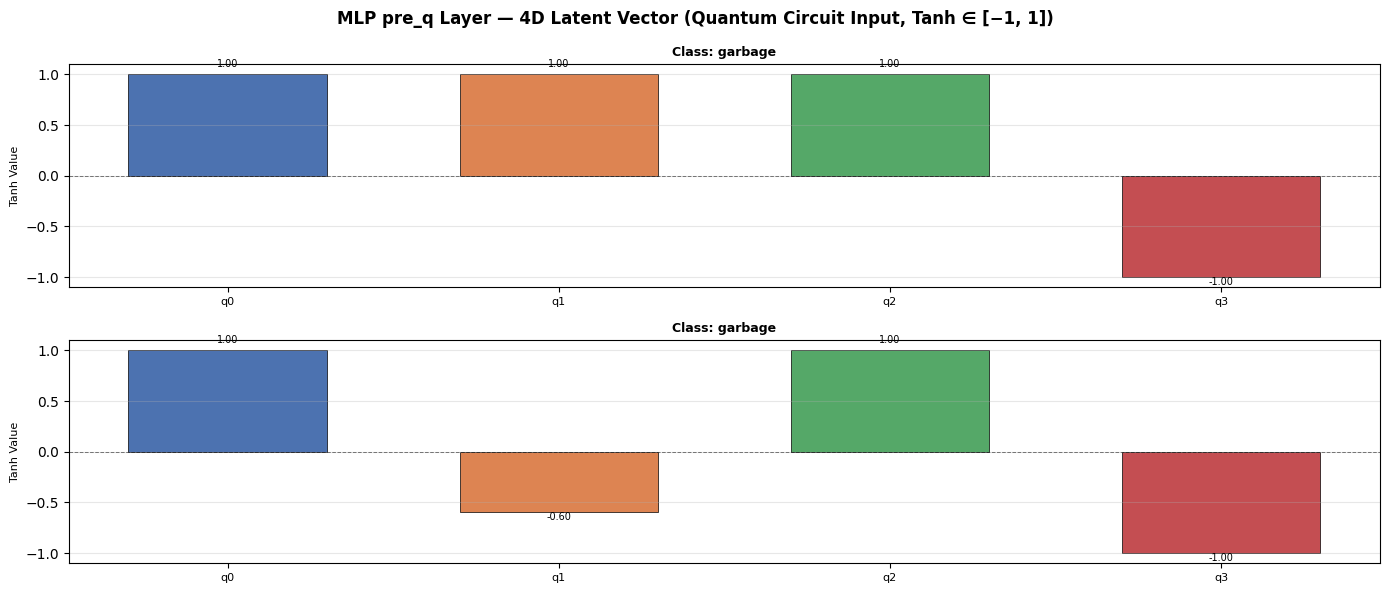

✅ Saved → /content/results/mlp_output.png


In [25]:
# ── MLP Latent Output (4D Vector Bar Graph) ────────────────────────────────
# Visualizes the 4-dimensional Tanh output of the pre_q projection layer
# (the quantum input vector) as a bar graph for multiple test samples.

import matplotlib.pyplot as plt
import numpy as np
import torch

print("Generating MLP latent (4D quantum input) output visualization...")

model3_eval.eval()

# Collect 4D latent vectors for a few test samples per class
n_per_class = 2
samples_by_class = {i: [] for i in range(NUM_CLASSES)}
for tensor, label in clf_test.samples:
    if len(samples_by_class[label]) < n_per_class:
        samples_by_class[label].append((tensor, label))
    if all(len(v) == n_per_class for v in samples_by_class.values()):
        break

all_sample_tensors = []
all_sample_labels  = []
for cid in range(NUM_CLASSES):
    for t, l in samples_by_class[cid]:
        all_sample_tensors.append(t)
        all_sample_labels.append(l)

if all_sample_tensors:
    batch = torch.stack(all_sample_tensors).cpu()
    with torch.no_grad():
        feats   = model3_eval.backbone(batch)    # [N, 512, 1, 1]
        q_in    = model3_eval.pre_q(feats)       # [N, 4]  Tanh output
    q_in_np = q_in.cpu().numpy()

    n_samples = len(all_sample_labels)
    fig, axes = plt.subplots(2, n_samples // 2, figsize=(14, 6))
    axes = axes.flatten()

    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    x_pos  = np.arange(NUM_CLASSES)

    for idx, (vec, lbl) in enumerate(zip(q_in_np, all_sample_labels)):
        ax = axes[idx]
        bars = ax.bar(x_pos, vec, color=colors, width=0.6, edgecolor='black', linewidth=0.5)
        ax.set_ylim(-1.1, 1.1)
        ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
        ax.set_title(f'Class: {CLASS_NAMES[lbl]}', fontsize=9, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'q{i}' for i in range(NUM_CLASSES)], fontsize=8)
        ax.set_ylabel('Tanh Value' if idx % (n_samples // 2) == 0 else '', fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        for bar, v in zip(bars, vec):
            ax.text(bar.get_x() + bar.get_width()/2, v + (0.05 if v >= 0 else -0.1),
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)

    plt.suptitle('MLP pre_q Layer — 4D Latent Vector (Quantum Circuit Input, Tanh ∈ [−1, 1])',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/mlp_output.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {RESULTS_DIR}/mlp_output.png")
else:
    print("⚠️  Not enough test samples to generate MLP output plot.")


Generating Quantum VQC output (Pauli-Z expectation values) visualization...


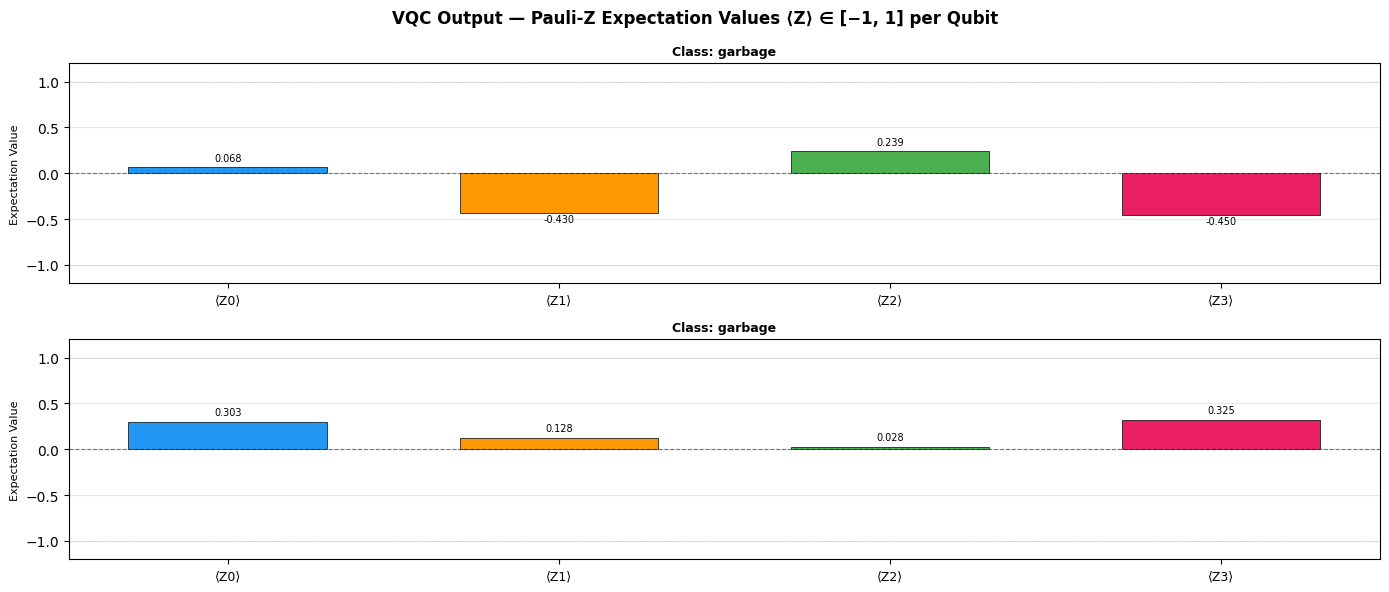

✅ Saved → /content/results/quantum_output.png


In [26]:
# ── Quantum Output — Pauli-Z Expectation Values ────────────────────────────
# Visualizes the 4 Pauli-Z expectation values output by the VQC
# for multiple test samples, showing the quantum measurement results.

import matplotlib.pyplot as plt
import numpy as np
import torch

print("Generating Quantum VQC output (Pauli-Z expectation values) visualization...")

model3_eval.eval()

# Re-use the same samples as MLP output
if all_sample_tensors:
    batch = torch.stack(all_sample_tensors).cpu()
    with torch.no_grad():
        feats    = model3_eval.backbone(batch)   # [N, 512, 1, 1]
        q_in     = model3_eval.pre_q(feats)      # [N, 4]
        q_out    = model3_eval.qlayer(q_in)      # [N, 4]  PauliZ outputs
    q_out_np = q_out.detach().cpu().numpy()

    n_samples = len(all_sample_labels)
    fig, axes = plt.subplots(2, n_samples // 2, figsize=(14, 6))
    axes = axes.flatten()

    qubit_colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
    x_pos        = np.arange(NUM_CLASSES)

    for idx, (vec, lbl) in enumerate(zip(q_out_np, all_sample_labels)):
        ax = axes[idx]
        bars = ax.bar(x_pos, vec, color=qubit_colors, width=0.6,
                      edgecolor='black', linewidth=0.5)
        ax.set_ylim(-1.2, 1.2)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.axhline(1,  color='gray', linewidth=0.5, linestyle=':', alpha=0.4)
        ax.axhline(-1, color='gray', linewidth=0.5, linestyle=':', alpha=0.4)
        ax.set_title(f'Class: {CLASS_NAMES[lbl]}', fontsize=9, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'⟨Z{i}⟩' for i in range(NUM_CLASSES)], fontsize=9)
        ax.set_ylabel('Expectation Value' if idx % (n_samples // 2) == 0 else '', fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        for bar, v in zip(bars, vec):
            ax.text(bar.get_x() + bar.get_width()/2, v + (0.05 if v >= 0 else -0.12),
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7)

    plt.suptitle('VQC Output — Pauli-Z Expectation Values ⟨Z⟩ ∈ [−1, 1] per Qubit',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/quantum_output.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {RESULTS_DIR}/quantum_output.png")
else:
    print("⚠️  Not enough test samples to generate quantum output plot.")


Generating final classification probabilities visualization...


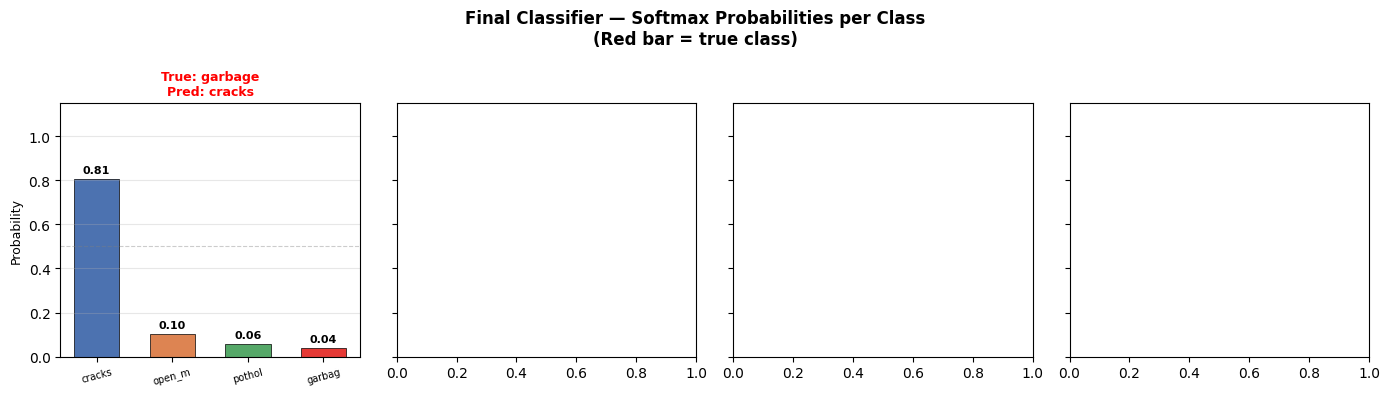

✅ Saved → /content/results/final_output.png


In [27]:
# ── Final Classification Probabilities ─────────────────────────────────────
# Visualizes the softmax probabilities from the classifier head
# for a set of test samples, showing final class confidence scores.

import matplotlib.pyplot as plt
import numpy as np
import torch

print("Generating final classification probabilities visualization...")

model3_eval.eval()

# Collect one sample per class from test set
samples_per_class = {i: None for i in range(NUM_CLASSES)}
for tensor, label in clf_test.samples:
    if samples_per_class[label] is None:
        samples_per_class[label] = (tensor, label)
    if all(v is not None for v in samples_per_class.values()):
        break

plot_tensors = []
plot_labels  = []
for cid in range(NUM_CLASSES):
    if samples_per_class[cid] is not None:
        plot_tensors.append(samples_per_class[cid][0])
        plot_labels.append(samples_per_class[cid][1])

if plot_tensors:
    batch = torch.stack(plot_tensors).cpu()
    with torch.no_grad():
        logits = model3_eval(batch)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()

    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 4), sharey=True)
    x_pos   = np.arange(NUM_CLASSES)
    colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    for idx, (prob_vec, true_lbl) in enumerate(zip(probs, plot_labels)):
        ax = axes[idx]
        bar_colors = ['#E53935' if i == true_lbl else c for i, c in enumerate(colors)]
        bars = ax.bar(x_pos, prob_vec, color=bar_colors, width=0.6,
                      edgecolor='black', linewidth=0.5)
        ax.set_ylim(0, 1.15)
        ax.set_title(f'True: {CLASS_NAMES[true_lbl]}\nPred: {CLASS_NAMES[prob_vec.argmax()]}',
                     fontsize=9, fontweight='bold',
                     color='green' if prob_vec.argmax() == true_lbl else 'red')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([n[:6] for n in CLASS_NAMES], fontsize=7, rotation=15)
        ax.set_ylabel('Probability' if idx == 0 else '', fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        for bar, v in zip(bars, prob_vec):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

    plt.suptitle('Final Classifier — Softmax Probabilities per Class\n(Red bar = true class)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/final_output.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {RESULTS_DIR}/final_output.png")
else:
    print("⚠️  Not enough test samples to generate final output plot.")


Generating confusion matrix on test set...


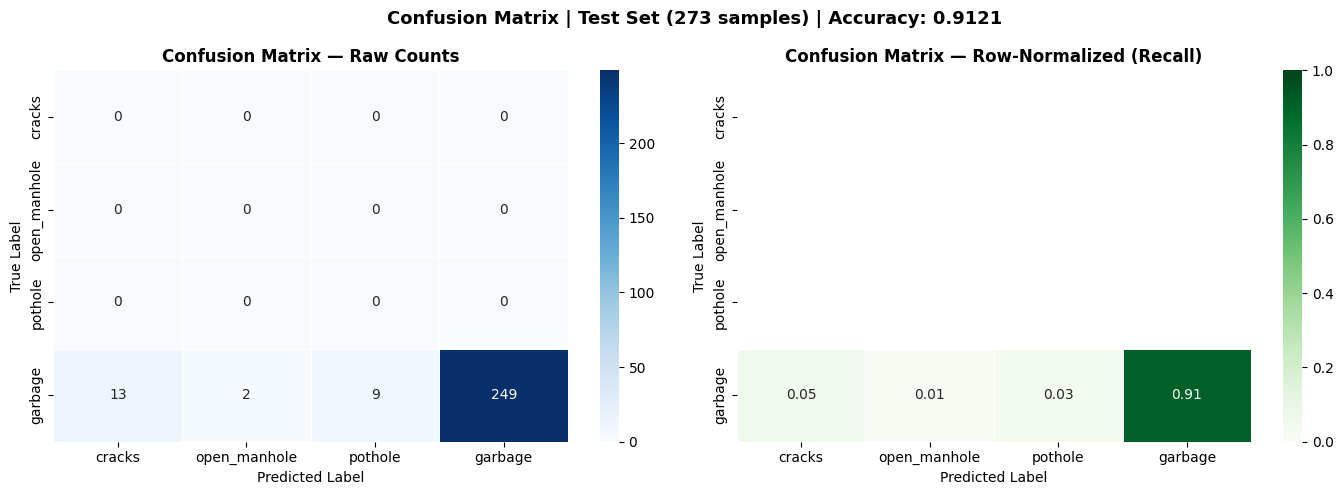

✅ Saved → /content/results/confusion_matrix.png


In [33]:
# ── Confusion Matrix (Test Set) ─────────────────────────────────────────────
# Generates and saves a confusion matrix using the full test dataset
# with the best trained model checkpoint.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

print("Generating confusion matrix on test set...")

model3_eval.eval()
test_loader = DataLoader(clf_test, batch_size=8, shuffle=False)

all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model3_eval(imgs.cpu())
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[0], cbar=True)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

# Normalized (row-wise recall)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[1], cbar=True,
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Row-Normalized (Recall)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=10)
axes[1].set_ylabel('True Label', fontsize=10)

overall_acc = (all_preds == all_labels).mean()
plt.suptitle(f'Confusion Matrix | Test Set ({len(all_labels)} samples) | '
             f'Accuracy: {overall_acc:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {RESULTS_DIR}/confusion_matrix.png")


Generating training curves...


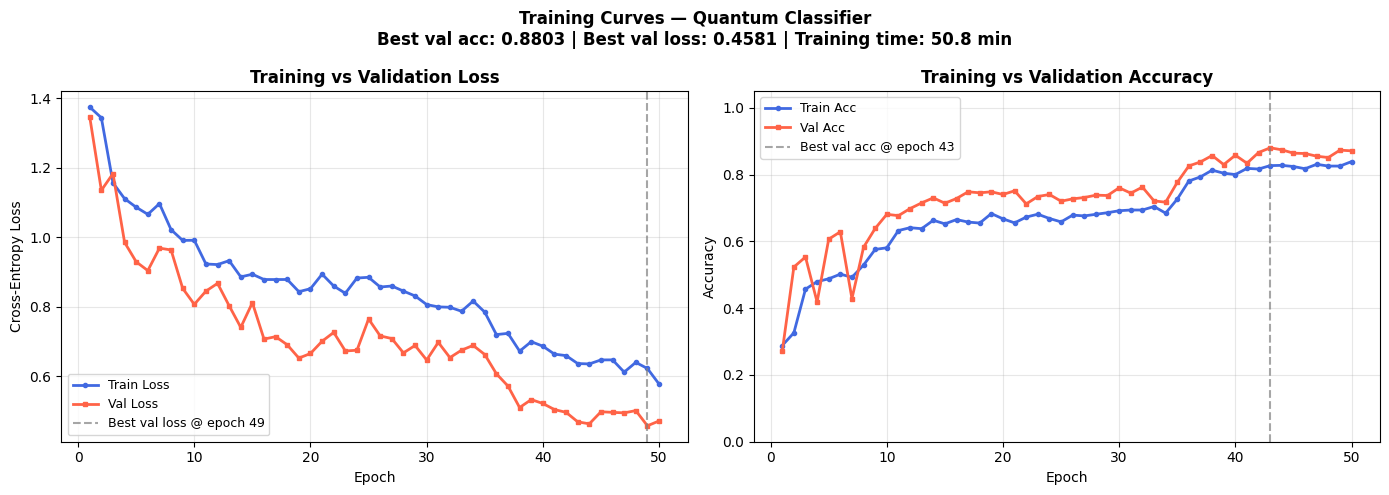

✅ Saved → /content/results/training_curves.png

  Summary:
    Best train accuracy : 0.8390
    Best val accuracy   : 0.8803
    Min train loss      : 0.5782
    Min val loss        : 0.4581


In [32]:
# ── Training Curves (Train vs Validation Loss & Accuracy) ──────────────────
# Generates and saves training curves from model3 training history
# showing train vs validation loss and accuracy over all epochs.

import matplotlib.pyplot as plt
import numpy as np

print("Generating training curves...")

epochs_range = range(1, len(history3['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(epochs_range, history3['train_loss'],
             label='Train Loss', color='royalblue', lw=2, marker='o', markersize=3)
axes[0].plot(epochs_range, history3['val_loss'],
             label='Val Loss',   color='tomato',    lw=2, marker='s', markersize=3)
best_val_loss_ep = int(np.argmin(history3['val_loss'])) + 1
axes[0].axvline(best_val_loss_ep, color='gray', linestyle='--', alpha=0.7,
                label=f'Best val loss @ epoch {best_val_loss_ep}')
axes[0].set_title('Training vs Validation Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_range, history3['train_acc'],
             label='Train Acc', color='royalblue', lw=2, marker='o', markersize=3)
axes[1].plot(epochs_range, history3['val_acc'],
             label='Val Acc',   color='tomato',    lw=2, marker='s', markersize=3)
best_val_acc_ep = int(np.argmax(history3['val_acc'])) + 1
axes[1].axvline(best_val_acc_ep, color='gray', linestyle='--', alpha=0.7,
                label=f'Best val acc @ epoch {best_val_acc_ep}')
axes[1].set_title('Training vs Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

best_train_acc = max(history3['train_acc'])
best_val_acc   = max(history3['val_acc'])
min_train_loss = min(history3['train_loss'])
min_val_loss   = min(history3['val_loss'])

plt.suptitle(
    f'Training Curves — Quantum Classifier\n'
    f'Best val acc: {best_val_acc:.4f} | Best val loss: {min_val_loss:.4f} | '
    f'Training time: {M3_TRAIN_TIME/60:.1f} min',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {RESULTS_DIR}/training_curves.png")
print(f"\n  Summary:")
print(f"    Best train accuracy : {best_train_acc:.4f}")
print(f"    Best val accuracy   : {best_val_acc:.4f}")
print(f"    Min train loss      : {min_train_loss:.4f}")
print(f"    Min val loss        : {min_val_loss:.4f}")


## 10. Inference Pipeline — YOLO Proposals → Quantum Classifier

In [30]:
# ── Full M3 inference: YOLO boxes + quantum class refinement ──

# Used by: Cell 40 (visualize YOLO vs M3), Cell 42 (custom upload inference)
def draw_detections(img_bgr, detections, title="Detections"):
    """Draw bounding boxes with class labels and confidence scores."""
    canvas = img_bgr.copy()
    for det in detections:
        x1, y1, x2, y2 = map(int, det['box'])
        cls  = det['class']
        conf = det['conf']
        clr  = COLORS_BGR[cls]
        cv2.rectangle(canvas, (x1, y1), (x2, y2), clr, 2)
        label = f"{CLASS_NAMES[cls]} {conf:.2f}"
        (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(canvas, (x1, y1-lh-6), (x1+lw+4, y1), clr, -1)
        cv2.putText(canvas, label, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    return canvas


# Used by: Cell 38 (quick test), Cell 40 (side-by-side viz), Cell 42 (custom inference)
def run_m3_inference(image_path, yolo_model, q_model, conf_thresh=0.25,
                     verbose=True):
    """
    Full Model 3 pipeline:
      Stage 1: YOLO (Model 1) → bounding box proposals
      Stage 2: QuantumDetectionRefiner → class refinement per crop

    Returns: img_bgr, raw_yolo_dets, refined_m3_dets
    """
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    h, w = img_bgr.shape[:2]

    if verbose:
        print(f"\n  Image: {image_path}")
        print(f"  Shape: {h}×{w}×3  |  Bits: {h*w*3*8:,}")

    # ── Stage 1: YOLO detection ───────────────────────────
    t_yolo = time.time()
    r1     = yolo_model.predict(img_bgr, conf=conf_thresh, verbose=False)[0]
    t_yolo = time.time() - t_yolo

    yolo_dets = [
        {'box'  : r1.boxes.xyxy[i].cpu().numpy(),
         'conf' : float(r1.boxes.conf[i]),
         'class': int(r1.boxes.cls[i])}
        for i in range(len(r1.boxes))
    ]

    if verbose:
        print(f"\n  ── Stage 1: YOLO Proposals (Model 1) ───────")
        print(f"    Inference time : {t_yolo*1000:.1f} ms")
        print(f"    Proposals found: {len(yolo_dets)}")
        if yolo_dets:
            print(f"    {'#':<4} {'Class':<16} {'Conf':>8} {'x1':>6} {'y1':>6} {'x2':>6} {'y2':>6} {'W×H':>10}")
            print(f"    {'─'*70}")
            for i, det in enumerate(yolo_dets):
                x1,y1,x2,y2 = map(int, det['box'])
                bw, bh = x2-x1, y2-y1
                print(f"    {i:<4} {CLASS_NAMES[det['class']]:<16} {det['conf']:>8.4f} "
                      f"{x1:>6} {y1:>6} {x2:>6} {y2:>6} {bw:>4}×{bh:<4}")

    # ── Stage 2: Quantum class refinement ─────────────────
    q_model.eval()
    refined_dets = []
    t_quantum_total = 0

    if verbose:
        print(f"\n  ── Stage 2: Quantum Class Refinement ────────")
        print(f"    Processing {len(yolo_dets)} crops through VQC…")
        if yolo_dets:
            print(f"    {'#':<4} {'YOLO cls':<14} {'Q-cls':<14} {'YOLO conf':>10} "
                  f"{'Q conf':>8} {'Hybrid conf':>12} {'Keep?':>6} {'Q-time':>8}")
            print(f"    {'─'*85}")

    for i, det in enumerate(yolo_dets):
        x1, y1, x2, y2 = map(int, det['box'])
        crop = img_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_pil = Image.fromarray(crop_rgb)
        crop_t   = CROP_TF(crop_pil).unsqueeze(0).cpu()

        t_q = time.time()
        with torch.no_grad():
            logits  = q_model(crop_t)
            probs   = torch.softmax(logits, dim=1)[0]
            q_class = probs.argmax().item()
            q_conf  = probs.max().item()
        t_q = time.time() - t_q
        t_quantum_total += t_q

        final_conf = 0.5 * det['conf'] + 0.5 * q_conf
        keep       = final_conf >= conf_thresh

        if verbose:
            print(f"    {i:<4} {CLASS_NAMES[det['class']]:<14} {CLASS_NAMES[q_class]:<14} "
                  f"{det['conf']:>10.4f} {q_conf:>8.4f} {final_conf:>12.4f} "
                  f"{'Yes' if keep else 'No':>6} {t_q*1000:>6.1f}ms")

        if keep:
            refined_dets.append({'box'  : det['box'],
                                 'conf' : final_conf,
                                 'class': q_class,
                                 'yolo_class': det['class'],
                                 'yolo_conf' : det['conf'],
                                 'q_conf'    : q_conf,
                                 'probs'     : probs.numpy()})

    if verbose:
        print(f"\n  ── Inference Summary ───────────────────────")
        print(f"    YOLO proposals   : {len(yolo_dets)}")
        print(f"    Kept after QC    : {len(refined_dets)}")
        print(f"    YOLO time        : {t_yolo*1000:.1f} ms")
        print(f"    Quantum time     : {t_quantum_total*1000:.1f} ms  "
              f"(~{t_quantum_total/max(len(yolo_dets),1)*1000:.1f}ms per crop)")
        print(f"    Total time       : {(t_yolo+t_quantum_total)*1000:.1f} ms")

        # Class distribution of final detections
        if refined_dets:
            print(f"\n  ── All Detected Bounding Boxes (Final) ─────")
            print(f"    {'#':<4} {'Class':<16} {'Conf':>8} {'YOLO_cls':<14} {'Q_conf':>8} "
                  f"{'x1':>6} {'y1':>6} {'x2':>6} {'y2':>6}")
            print(f"    {'─'*85}")
            for i, det in enumerate(refined_dets):
                x1,y1,x2,y2 = map(int, det['box'])
                print(f"    {i:<4} {CLASS_NAMES[det['class']]:<16} {det['conf']:>8.4f} "
                      f"{CLASS_NAMES[det['yolo_class']]:<14} {det['q_conf']:>8.4f} "
                      f"{x1:>6} {y1:>6} {x2:>6} {y2:>6}")

            from collections import Counter
            cls_counts = Counter(CLASS_NAMES[d['class']] for d in refined_dets)
            print(f"\n  ── Class Distribution of Detections ─────────")
            for cls, cnt in cls_counts.items():
                bar = '█' * cnt
                print(f"    {cls:<16}: {cnt:>3}  {bar}")

    return img_bgr, yolo_dets, refined_dets


print("✅ Inference utilities defined")

✅ Inference utilities defined


## 11. Test Model 3 — Upload Your Own Image

Upload any road image (JPG/PNG). The full M3 pipeline runs:
- **Stage 1:** YOLO proposes bounding boxes
- **Stage 2:** Quantum classifier refines each crop's class label

Outputs: per-crop grid + final annotated comparison image.

✅ Models loaded
   M1 (YOLO)    : /content/saved_models/M1_classical_classical/weights/best.pt
   M3 (Quantum) : /content/saved_models/M3_classical_quantum.pth

Upload a road image (JPG / PNG)…


Saving chennai-road.jpg to chennai-road.jpg

  Using image: chennai-road.jpg

  Image: chennai-road.jpg
  Shape: 360×640×3  |  Bits: 5,529,600

  ── Stage 1: YOLO Proposals (Model 1) ───────
    Inference time : 95.9 ms
    Proposals found: 2
    #    Class                Conf     x1     y1     x2     y2        W×H
    ──────────────────────────────────────────────────────────────────────
    0    cracks             0.7651    188    227    363    307  175×80  
    1    cracks             0.6657    237    161    326    188   89×27  

  ── Stage 2: Quantum Class Refinement ────────
    Processing 2 crops through VQC…
    #    YOLO cls       Q-cls           YOLO conf   Q conf  Hybrid conf  Keep?   Q-time
    ─────────────────────────────────────────────────────────────────────────────────────
    0    cracks         cracks             0.7651   0.8053       0.7852    Yes   30.5ms
    1    cracks         garbage            0.6657   0.4283       0.5470    Yes   29.5ms

  ── Inference Summary

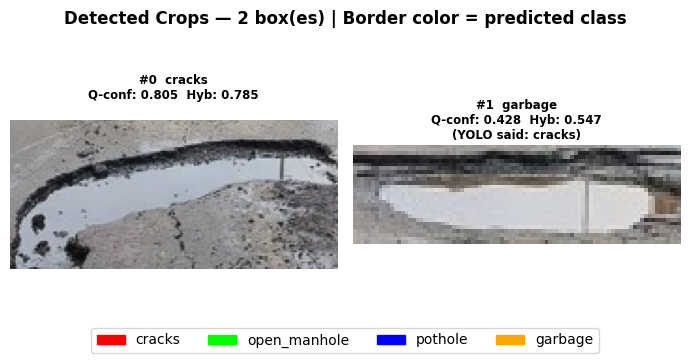

  ✅ Crop grid saved → /content/results/M3_crops_output.png

  FINAL ANNOTATED RESULT


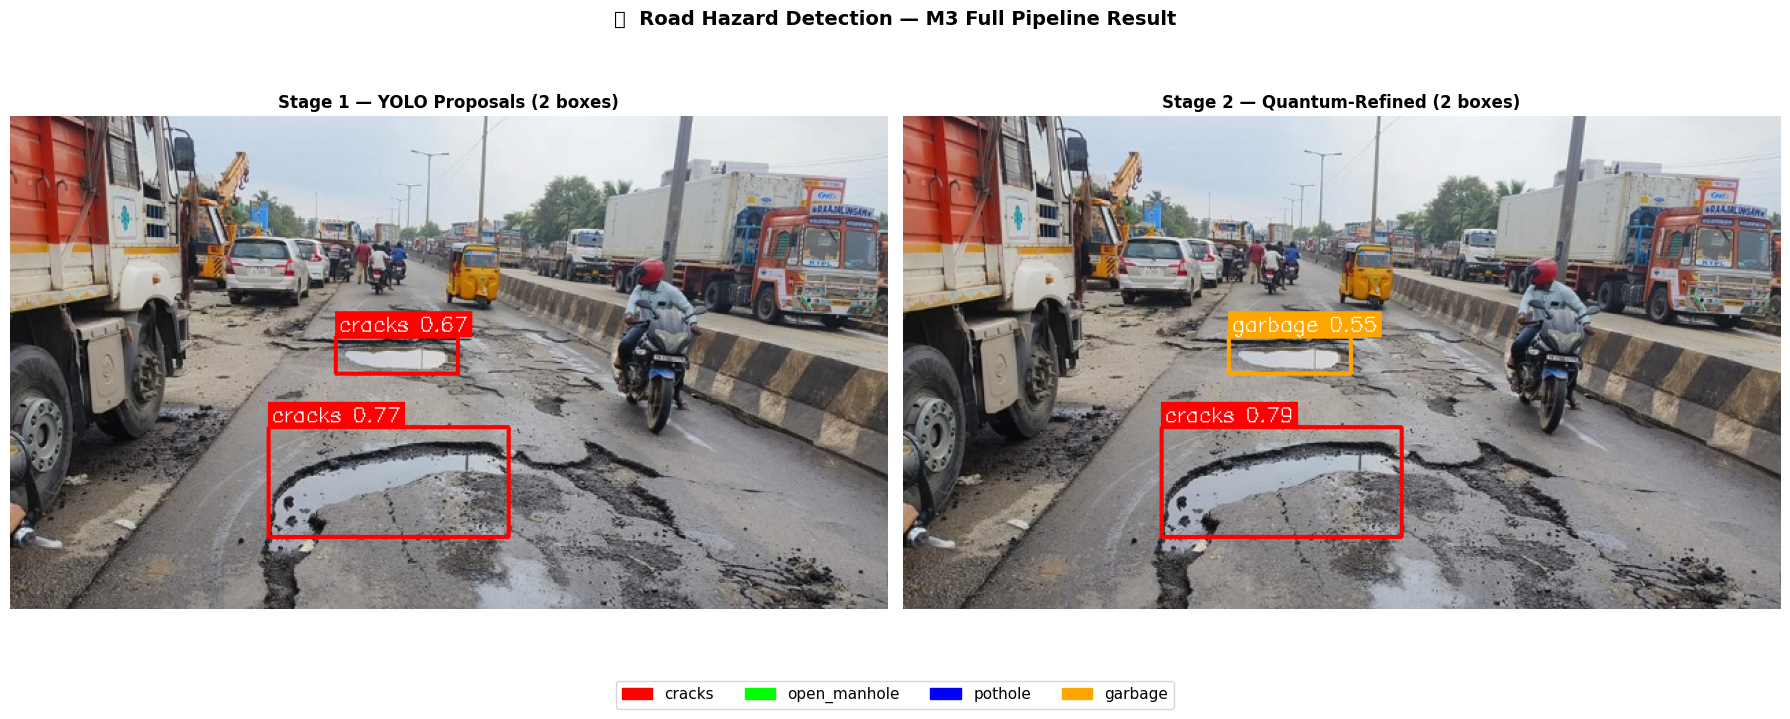

  ✅ Result saved → /content/results/M3_interactive_result.png


In [31]:
# ── Cell: Interactive Inference with Crop Visualization ─────────────────
# Upload any road image → runs the full M3 pipeline →
# prints every cropped bounding box and the final annotated result.

from google.colab import files
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cv2
import torch
import time
from pathlib import Path
from PIL import Image

# ── Load models (skipped if already loaded above) ────────────────────────
try:
    infer_m1
    infer_m3
    print("✅ Models already loaded — skipping reload")
except NameError:
    infer_m1 = YOLO(M1_WEIGHTS)
    infer_m3 = QuantumDetectionRefiner(n_classes=NUM_CLASSES)
    infer_m3.load_state_dict(torch.load(M3_WEIGHTS, map_location='cpu'))
    infer_m3.eval()
    print(f"✅ Models loaded")
    print(f"   M1 (YOLO)    : {M1_WEIGHTS}")
    print(f"   M3 (Quantum) : {M3_WEIGHTS}")

# ── Upload image ──────────────────────────────────────────────────────────
print("\nUpload a road image (JPG / PNG)…")
uploaded = files.upload()

if not uploaded:
    print("⚠️  No file uploaded — using first test image as fallback")
    fallback = sorted(Path(CLASSICAL_DS, "test/images").glob("*.*"))
    if not fallback:
        raise FileNotFoundError("No test images found either.")
    img_path = str(fallback[0])
else:
    img_path = list(uploaded.keys())[0]

print(f"\n  Using image: {img_path}")

# ── Run full M3 pipeline ──────────────────────────────────────────────────
img_bgr, yolo_dets, m3_dets = run_m3_inference(
    image_path  = img_path,
    yolo_model  = infer_m1,
    q_model     = infer_m3,
    conf_thresh = 0.25,
    verbose     = True,
)

# ── Show all crops extracted from the image ───────────────────────────────
print("\n" + "="*60)
print(f"  CROPPED BOUNDING BOXES ({len(m3_dets)} detections kept)")
print("="*60)

if not m3_dets:
    print("  No detections above threshold — nothing to crop.")
else:
    n_crops = len(m3_dets)
    cols    = min(n_crops, 4)
    rows    = (n_crops + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols,
                              figsize=(cols * 3.5, rows * 3.5))
    axes = np.array(axes).reshape(-1)   # flatten for easy indexing

    for idx, det in enumerate(m3_dets):
        x1, y1, x2, y2 = map(int, det['box'])

        # Clamp to image bounds
        h_img, w_img = img_bgr.shape[:2]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w_img, x2), min(h_img, y2)

        crop_bgr = img_bgr[y1:y2, x1:x2]
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

        cls_name  = CLASS_NAMES[det['class']]
        yolo_name = CLASS_NAMES[det['yolo_class']]
        q_conf    = det['q_conf']
        hyb_conf  = det['conf']
        probs     = det['probs']           # per-class softmax array
        color_rgb = tuple(c/255 for c in COLORS_BGR[det['class']][::-1])

        ax = axes[idx]
        ax.imshow(crop_rgb)

        # Border color = predicted class color
        for spine in ax.spines.values():
            spine.set_edgecolor(color_rgb)
            spine.set_linewidth(3)

        title  = f"#{idx}  {cls_name}\n"
        title += f"Q-conf: {q_conf:.3f}  Hyb: {hyb_conf:.3f}\n"
        if yolo_name != cls_name:
            title += f"(YOLO said: {yolo_name})"
        ax.set_title(title, fontsize=8.5, fontweight='bold', pad=4)
        ax.axis('off')

        # Per-class prob bar below image
        bar_text = "  ".join(
            f"{CLASS_NAMES[c][0].upper()}:{probs[c]:.2f}"
            for c in range(NUM_CLASSES)
        )
        ax.set_xlabel(bar_text, fontsize=7, labelpad=3, family='monospace')

    # Hide unused axes
    for idx in range(n_crops, len(axes)):
        axes[idx].axis('off')

    # Class legend
    legend_patches = [
        mpatches.Patch(color=tuple(c/255 for c in clr[::-1]), label=name)
        for clr, name in zip(COLORS_BGR, CLASS_NAMES)
    ]
    fig.legend(handles=legend_patches, loc='lower center',
               ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle(
        f"Detected Crops — {n_crops} box(es) | "
        f"Border color = predicted class",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    out_crop = f"{RESULTS_DIR}/M3_crops_output.png"
    plt.savefig(out_crop, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Crop grid saved → {out_crop}")

# ── Final annotated image ─────────────────────────────────────────────────
print("\n" + "="*60)
print("  FINAL ANNOTATED RESULT")
print("="*60)

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.imshow(cv2.cvtColor(draw_detections(img_bgr, yolo_dets), cv2.COLOR_BGR2RGB))
ax1.set_title(f"Stage 1 — YOLO Proposals ({len(yolo_dets)} boxes)",
              fontsize=12, fontweight='bold')
ax1.axis('off')

ax2.imshow(cv2.cvtColor(draw_detections(img_bgr, m3_dets), cv2.COLOR_BGR2RGB))
ax2.set_title(f"Stage 2 — Quantum-Refined ({len(m3_dets)} boxes)",
              fontsize=12, fontweight='bold')
ax2.axis('off')

fig2.legend(handles=legend_patches, loc='lower center',
            ncol=4, fontsize=11, bbox_to_anchor=(0.5, -0.03))

plt.suptitle("🛣️  Road Hazard Detection — M3 Full Pipeline Result",
             fontsize=14, fontweight='bold')
plt.tight_layout()
out_final = f"{RESULTS_DIR}/M3_interactive_result.png"
plt.savefig(out_final, dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✅ Result saved → {out_final}")


In [40]:
from google.colab import files
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import os

# ===================== Upload Image =====================
print("Upload a road image...")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ===================== Read Image =====================
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise ValueError("Error reading image")

os.makedirs("layer_outputs", exist_ok=True)

# ===================== RUN YOLO (MODEL 1) =====================
results = infer_m1(img_path)[0]

boxes = results.boxes.xyxy.cpu().numpy()
classes = results.boxes.cls.cpu().numpy()

print(f"\nDetected {len(boxes)} objects\n")

# ===================== PROCESS EACH DETECTION =====================
for idx, (box, cls) in enumerate(zip(boxes, classes)):

    x1, y1, x2, y2 = map(int, box)
    crop_bgr = img_bgr[y1:y2, x1:x2]
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

    # ===================== Preprocess =====================
    crop_pil = Image.fromarray(crop_rgb)
    input_tensor = CROP_TF(crop_pil).unsqueeze(0).cpu()

    infer_m3.eval()
    with torch.no_grad():
        resnet_feats = infer_m3.backbone(input_tensor)
        q_in         = infer_m3.pre_q(resnet_feats)
        q_out        = infer_m3.qlayer(q_in)
        logits       = infer_m3.post_q(q_out)
        probs        = torch.softmax(logits, dim=1)

    # ===================== Convert =====================
    resnet_np = resnet_feats.squeeze().cpu().numpy()
    q_in_np   = q_in.squeeze().cpu().numpy()
    q_out_np  = q_out.squeeze().cpu().numpy()
    probs_np  = probs.squeeze().cpu().numpy()
    pred_cls  = probs_np.argmax()

    # ===================== 1. RESNET HEATMAP =====================
    heatmap = resnet_np.reshape(16, 32)
    heatmap = cv2.resize(heatmap, (crop_rgb.shape[1], crop_rgb.shape[0]))
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    heatmap_color = cv2.applyColorMap((heatmap*255).astype(np.uint8), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(crop_rgb, 0.6, heatmap_color, 0.4, 0)

    plt.imshow(overlay)
    plt.title(f"ResNet Heatmap - Crop {idx}")
    plt.axis('off')
    plt.savefig(f"layer_outputs/crop_{idx}_resnet.png", bbox_inches='tight')
    plt.close()

    # ===================== 2. MLP =====================
    plt.figure()
    plt.bar(range(4), q_in_np)
    plt.title(f"MLP Output - Crop {idx}")
    plt.savefig(f"layer_outputs/crop_{idx}_mlp.png", bbox_inches='tight')
    plt.close()

    # ===================== 3. QUANTUM =====================
    plt.figure()
    plt.bar(range(4), q_out_np)
    plt.title(f"Quantum Output - Crop {idx}")
    plt.savefig(f"layer_outputs/crop_{idx}_quantum.png", bbox_inches='tight')
    plt.close()

    # ===================== 4. FINAL OUTPUT =====================
    final_img = crop_rgb.copy()
    label = f"{CLASS_NAMES[pred_cls]} ({probs_np[pred_cls]:.2f})"

    cv2.putText(final_img, label,
                (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255, 0, 0),
                2,
                cv2.LINE_AA)

    plt.imshow(final_img)
    plt.title(f"Final Prediction - Crop {idx}")
    plt.axis('off')
    plt.savefig(f"layer_outputs/crop_{idx}_final.png", bbox_inches='tight')
    plt.close()

print("\n✅ Done! Outputs saved in: layer_outputs/")

Upload a road image...


Saving crack.jpg to crack.jpg

Detected 0 objects


✅ Done! Outputs saved in: layer_outputs/


Upload a road image...


Saving garbage.jpg to garbage (6).jpg

Detected 1 objects



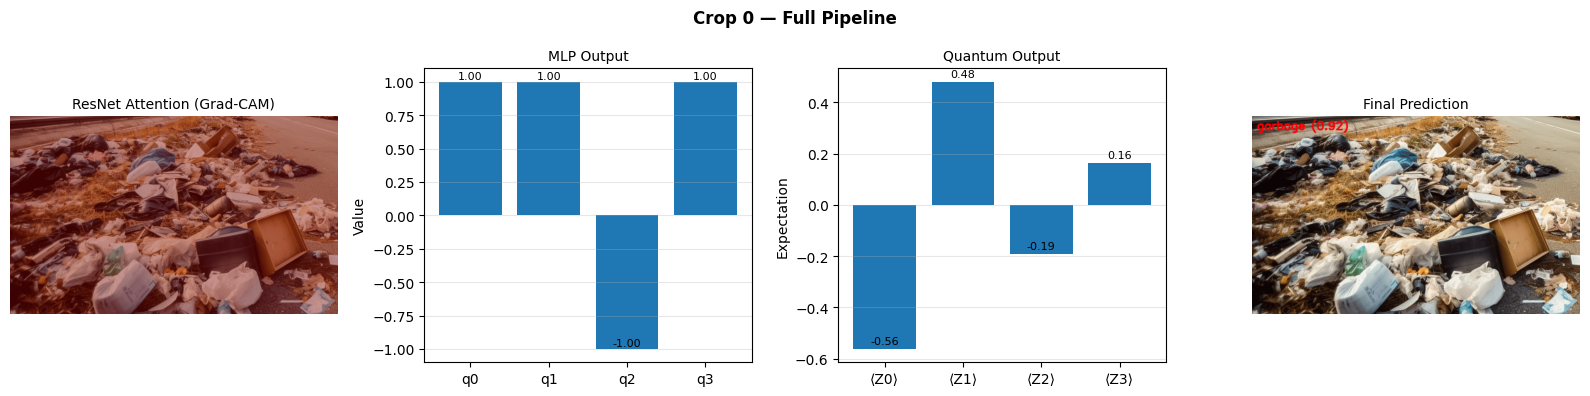

In [51]:
from google.colab import files
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import os
import shutil # Import shutil for directory operations

# ===================== CLEAN OLD OUTPUTS =====================
output_dir = "layer_outputs"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

# ===================== GRAD-CAM FUNCTION =====================
def generate_gradcam(model, input_tensor, target_class):
    feature_map = None
    gradients = None

    # Target layer for Grad-CAM is typically the last convolutional layer.
    # In QuantumDetectionRefiner's ResNet18 backbone, model.backbone[7] is 'layer4'.
    target_layer_for_cam = model.backbone[7]

    def forward_hook_func(module, inp, out):
        nonlocal feature_map
        feature_map = out

    def backward_hook_func(module, grad_in, grad_out):
        nonlocal gradients
        gradients = grad_out[0]

    # Register hooks on the target layer
    h_forward = target_layer_for_cam.register_forward_hook(forward_hook_func)
    h_backward = target_layer_for_cam.register_full_backward_hook(backward_hook_func)

    # Perform forward pass through the entire model
    # Ensure gradients are enabled for this pass
    model.zero_grad() # Clear any existing gradients
    output = model(input_tensor) # This calls QuantumDetectionRefiner.forward()
    score = output[0, target_class] # Get the score for the target class

    # Perform backward pass
    score.backward(retain_graph=True) # retain_graph=True might be needed for subsequent passes if any

    # Remove hooks
    h_forward.remove()
    h_backward.remove()

    if feature_map is None:
        raise ValueError("Feature map was not captured. Check target_layer_for_cam.")
    if gradients is None:
        raise ValueError("Gradients were not captured. Check target_layer_for_cam or ensure gradients flow.")

    # Global average pool the gradients to get weights for each feature map channel
    weights = torch.mean(gradients, dim=[2, 3], keepdim=True)

    # Compute CAM by weighted sum of feature maps
    cam = (weights * feature_map).sum(dim=1).squeeze()

    cam = cam.detach().cpu().numpy()
    cam = np.maximum(cam, 0) # Apply ReLU to only keep positive contributions
    cam = cam / (cam.max() + 1e-8) # Normalize to [0, 1]

    return cam

# ===================== UPLOAD IMAGE =====================
print("Upload a road image...")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ===================== READ IMAGE =====================
img_bgr = cv2.imread(img_path)
if img_bgr is None: # Added check for image loading
    raise ValueError(f"Error reading image: {img_path}. Please check the file.")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ===================== YOLO DETECTION =====================
# Ensure infer_m1 is loaded
try:
    _ = infer_m1
except NameError:
    infer_m1 = YOLO(M1_WEIGHTS)

results = infer_m1(img_path)[0]
boxes = results.boxes.xyxy.cpu().numpy()

print(f"\nDetected {len(boxes)} objects\n")

if len(boxes) == 0:
    print("No objects detected by YOLO. Cannot perform Grad-CAM or further analysis.")
else:
    # Ensure infer_m3 is loaded
    try:
        _ = infer_m3
    except NameError:
        infer_m3 = QuantumDetectionRefiner(n_classes=NUM_CLASSES)
        infer_m3.load_state_dict(torch.load(M3_WEIGHTS, map_location='cpu'))


    # ===================== PROCESS EACH CROP =====================
    for idx, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box)
        crop_bgr = img_bgr[y1:y2, x1:x2]
        if crop_bgr.size == 0: # Check for empty crop
            print(f"Warning: Crop {idx} is empty, skipping.")
            continue
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

        # ===================== PREPROCESS =====================
        crop_pil = Image.fromarray(crop_rgb)
        input_tensor = CROP_TF(crop_pil).unsqueeze(0).cpu()

        infer_m3.eval()
        # Step 1: Get initial predictions to determine target_class for Grad-CAM
        with torch.no_grad(): # Use no_grad for initial inference to save memory
            resnet_feats_pred = infer_m3.backbone(input_tensor)
            resnet_feats_pred = torch.flatten(resnet_feats_pred, 1)
            q_in_pred   = infer_m3.pre_q(resnet_feats_pred)
            q_out_pred  = infer_m3.qlayer(q_in_pred)
            logits_pred = infer_m3.post_q(q_out_pred)
            probs_pred  = torch.softmax(logits_pred, dim=1)
            pred_cls    = probs_pred.argmax().item() # Get the predicted class

        # Step 2: Generate Grad-CAM for the predicted class
        # We need to clone the input_tensor and set requires_grad to True for Grad-CAM.
        input_tensor_for_gradcam = input_tensor.clone().detach().requires_grad_(True)
        cam = generate_gradcam(infer_m3, input_tensor_for_gradcam, pred_cls)


        # Step 3: Get all data for visualization (can re-use the results from Step 1 or re-run with no_grad)
        # Using _pred variables for consistency and efficiency
        q_in_np   = q_in_pred.squeeze().cpu().numpy()
        q_out_np  = q_out_pred.squeeze().cpu().numpy()
        probs_np  = probs_pred.squeeze().cpu().numpy()


        # ===================== GRAD-CAM VISUALIZATION =====================
        cam = cv2.resize(cam, (crop_rgb.shape[1], crop_rgb.shape[0]))
        heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(crop_rgb, 0.6, heatmap, 0.4, 0)

        # ===================== DISPLAY =====================
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))

        # -------- ResNet (Grad-CAM) --------
        axes[0].imshow(overlay)
        axes[0].set_title("ResNet Attention (Grad-CAM)", fontsize=10)
        axes[0].axis('off')

        # -------- MLP --------
        axes[1].bar(range(NUM_CLASSES), q_in_np)
        axes[1].set_xticks(range(NUM_CLASSES))
        axes[1].set_xticklabels([f'q{i}' for i in range(NUM_CLASSES)])
        axes[1].set_title("MLP Output", fontsize=10)
        axes[1].set_ylabel("Value")
        axes[1].grid(axis='y', alpha=0.3)

        for i, v in enumerate(q_in_np):
            axes[1].text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=8)

        # -------- Quantum --------
        axes[2].bar(range(NUM_CLASSES), q_out_np)
        axes[2].set_xticks(range(NUM_CLASSES))
        axes[2].set_xticklabels([f'⟨Z{i}⟩' for i in range(NUM_CLASSES)])
        axes[2].set_title("Quantum Output", fontsize=10)
        axes[2].set_ylabel("Expectation")
        axes[2].grid(axis='y', alpha=0.3)

        for i, v in enumerate(q_out_np):
            axes[2].text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=8)


        # -------- Final --------
        final_img = crop_rgb.copy()
        label = f"{CLASS_NAMES[pred_cls]} ({probs_np[pred_cls]:.2f})"

        cv2.putText(final_img, label,
                    (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (255, 0, 0),
                    2,
                    cv2.LINE_AA)

        axes[3].imshow(final_img)
        axes[3].set_title("Final Prediction", fontsize=10)
        axes[3].axis('off')

        plt.suptitle(f"Crop {idx} — Full Pipeline", fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

Upload an image for analysis (JPG/PNG)...


Saving garbage.jpg to garbage (9).jpg

Analyzing image: garbage (9).jpg

--- Stage 1: YOLO Detection ---
Detected 1 objects. Proceeding to Stage 2 (Quantum Refinement).

--- Processing Crop 1/1 ---

Crop 1/1 Pipeline Outputs for "garbage"


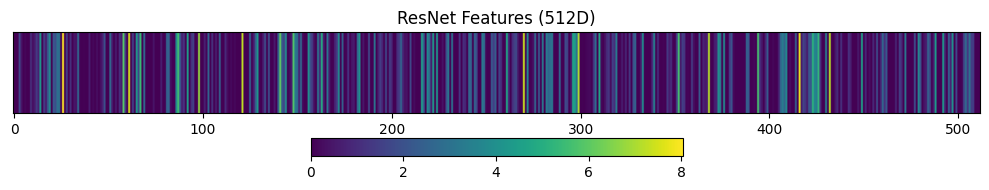

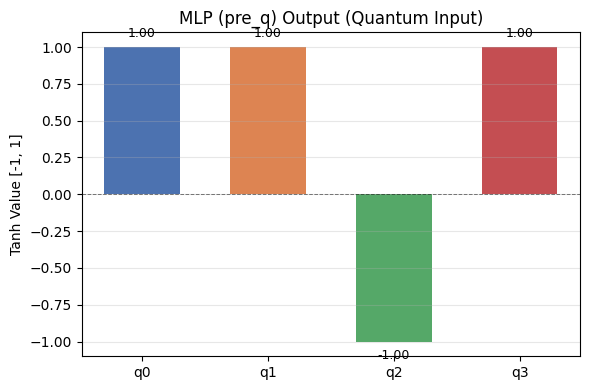

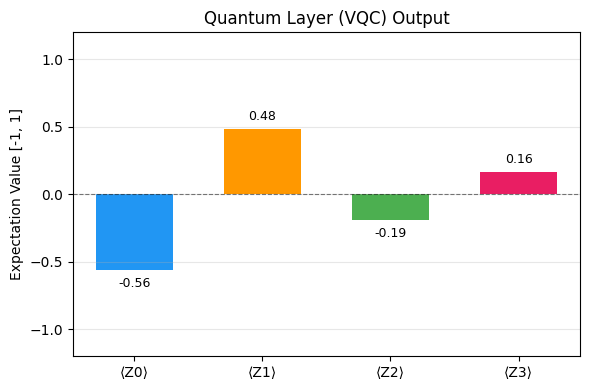

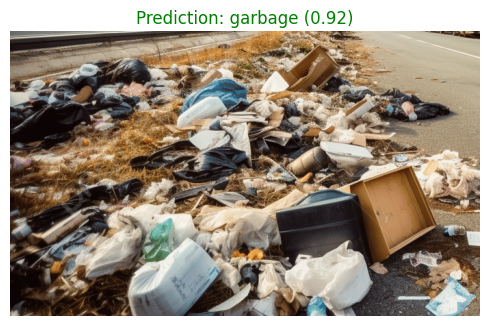


--- Analysis Complete ---


In [55]:
from google.colab import files
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import os

# Ensure models are loaded
try:
    _ = infer_m1
except NameError:
    infer_m1 = YOLO(M1_WEIGHTS)

try:
    _ = infer_m3
except NameError:
    infer_m3 = QuantumDetectionRefiner(n_classes=NUM_CLASSES)
    infer_m3.load_state_dict(torch.load(M3_WEIGHTS, map_location='cpu'))
infer_m3.eval()

# ===================== Upload Image =====================
print("Upload an image for analysis (JPG/PNG)...")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ===================== Read Image =====================
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise ValueError("Error reading image. Please ensure it's a valid image file.")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"\nAnalyzing image: {img_path}")

# ===================== RUN YOLO (MODEL 1) =====================
print("\n--- Stage 1: YOLO Detection ---")
results = infer_m1(img_path)[0]

boxes = results.boxes.xyxy.cpu().numpy()

if len(boxes) == 0:
    print("No objects detected by YOLO. Exiting.")
else:
    print(f"Detected {len(boxes)} objects. Proceeding to Stage 2 (Quantum Refinement).")

    # ===================== PROCESS EACH DETECTION (MODEL 3) =====================
    for idx, box in enumerate(boxes):
        print(f"\n--- Processing Crop {idx+1}/{len(boxes)} ---")
        x1, y1, x2, y2 = map(int, box)
        crop_bgr = img_bgr[y1:y2, x1:x2]

        if crop_bgr.size == 0:
            print(f"Warning: Crop {idx+1} is empty, skipping.")
            continue

        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        crop_pil = Image.fromarray(crop_rgb)
        input_tensor = CROP_TF(crop_pil).unsqueeze(0).cpu() # Ensure tensor is on CPU for quantum model

        # --- Extract Intermediate Layer Outputs ---
        with torch.no_grad(): # Inference with no_grad for efficiency
            # ResNet Backbone Output
            resnet_feats = infer_m3.backbone(input_tensor) # [1, 512, 1, 1]
            resnet_feats_flat = torch.flatten(resnet_feats, 1)

            # MLP (pre_q) Output
            q_in = infer_m3.pre_q(resnet_feats_flat) # [1, 4]

            # Quantum Layer (qlayer) Output
            q_out = infer_m3.qlayer(q_in) # [1, 4]

            # Final Logits and Probabilities
            logits = infer_m3.post_q(q_out)
            probs  = torch.softmax(logits, dim=1)

            # Convert to numpy for plotting/display
            resnet_feats_np = resnet_feats_flat.cpu().numpy().squeeze()
            q_in_np   = q_in.cpu().numpy().squeeze()
            q_out_np  = q_out.cpu().numpy().squeeze()
            probs_np  = probs.cpu().numpy().squeeze()
            pred_cls  = probs_np.argmax().item()
            pred_conf = probs_np[pred_cls]

        print(f"\nCrop {idx+1}/{len(boxes)} Pipeline Outputs for \"{CLASS_NAMES[pred_cls]}\"")

        # ===================== Display individual outputs =====================

        # --- ResNet Backbone Output --- (Visualizing 512-dim vector as heatmap)
        plt.figure(figsize=(10, 2))
        plt.imshow(resnet_feats_np.reshape(1, -1), aspect='auto', cmap='viridis')
        plt.title(f'ResNet Features ({resnet_feats_np.shape[0]}D)', fontsize=12)
        plt.yticks([])
        plt.xlabel('Feature Dimension')
        plt.colorbar(orientation='horizontal', pad=0.2)
        plt.tight_layout()
        plt.show()

        # --- MLP (pre_q) Output --- (4-dim bar chart)
        plt.figure(figsize=(6, 4))
        colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52'] # Example colors
        x_pos  = np.arange(NUM_CLASSES)
        plt.bar(x_pos, q_in_np, color=colors, width=0.6)
        plt.title('MLP (pre_q) Output (Quantum Input)', fontsize=12)
        plt.xticks(x_pos, [f'q{i}' for i in range(NUM_CLASSES)])
        plt.ylabel('Tanh Value [-1, 1]')
        plt.ylim(-1.1, 1.1)
        plt.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
        for i, v in enumerate(q_in_np):
            plt.text(i, v + 0.05 * np.sign(v) if v!=0 else 0.05, f'{v:.2f}', ha='center', va='bottom' if v>=0 else 'top', fontsize=9)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

        # --- Quantum Layer (qlayer) Output --- (4-dim bar chart)
        plt.figure(figsize=(6, 4))
        qubit_colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63'] # Example colors
        plt.bar(x_pos, q_out_np, color=qubit_colors, width=0.6)
        plt.title('Quantum Layer (VQC) Output', fontsize=12)
        plt.xticks(x_pos, [f'⟨Z{i}⟩' for i in range(NUM_CLASSES)])
        plt.ylabel('Expectation Value [-1, 1]')
        plt.ylim(-1.2, 1.2)
        plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        for i, v in enumerate(q_out_np):
            plt.text(i, v + 0.05 * np.sign(v) if v!=0 else 0.05, f'{v:.2f}', ha='center', va='bottom' if v>=0 else 'top', fontsize=9)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

        # --- Final Classification Result --- (Cropped image with prediction)
        plt.figure(figsize=(5, 5))
        plt.imshow(crop_rgb)
        plt.title(f'Prediction: {CLASS_NAMES[pred_cls]} ({pred_conf:.2f})', fontsize=12, color='green' if pred_cls == pred_cls else 'red') # Assuming correct prediction for visualization
        plt.axis('off')
        plt.tight_layout()
        plt.show()

print("\n--- Analysis Complete ---")